# 🍬 Nassau Candy Distributor
## Factory-to-Customer Shipping Route Efficiency — EDA

**Objective:** Transform raw order & shipment data into route-level operational intelligence to improve logistics performance, reduce delays, and enhance nationwide delivery reliability.

| Field | Details |
|-------|---------|
| Dataset | Nassau Candy Distributor Orders |
| Rows | ~10,194 orders |
| Factories | 5 (Lot's O' Nuts, Wicked Choccy's, Sugar Shack, Secret Factory, The Other Factory) |
| Regions | Interior · Atlantic · Gulf · Pacific |

---


---
## Step 1 — Environment Setup & Imports

In [1498]:
# 1.1 — Imports & Configuration
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import os

%matplotlib inline

OUTPUT_DIR = "eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Delay threshold: 7 days is valid because Ship Date is regenerated
# from Order Date using realistic ship-mode lead times (see Cell 7).
DELAY_THRESHOLD_DAYS = 7
PALETTE = "Set2"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


---
## Step 2 — Lookup Tables — Factory & Product Mapping

In [1499]:
# 2.1 — Lookup Tables: Factory & Product Mapping
PRODUCT_FACTORY = {
    "Wonka Bar - Nutty Crunch Surprise":   "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows":           "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious":      "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate":          "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel":   "Wicked Choccy's",
    "Laffy Taffy":                         "Sugar Shack",
    "SweeTARTS":                           "Sugar Shack",
    "Nerds":                               "Sugar Shack",
    "Fun Dip":                             "Sugar Shack",
    "Fizzy Lifting Drinks":                "Sugar Shack",
    "Everlasting Gobstopper":              "Secret Factory",
    "Lickable Wallpaper":                  "Secret Factory",
    "Wonka Gum":                           "Secret Factory",
    "Hair Toffee":                         "The Other Factory",
    "Kazookles":                           "The Other Factory",
}

FACTORY_COORDS = {
    "Lot's O' Nuts":     (32.881893, -111.768036),
    "Wicked Choccy's":   (32.076176,  -81.088371),
    "Sugar Shack":       (48.119140,  -96.181150),
    "Secret Factory":    (41.446333,  -90.565487),
    "The Other Factory": (35.117500,  -89.971107),
}

STATE_ABBREV = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR",
    "California":"CA","Colorado":"CO","Connecticut":"CT","Delaware":"DE",
    "Florida":"FL","Georgia":"GA","Hawaii":"HI","Idaho":"ID",
    "Illinois":"IL","Indiana":"IN","Iowa":"IA","Kansas":"KS",
    "Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
    "Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS",
    "Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV",
    "New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM","New York":"NY",
    "North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK",
    "Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC",
    "South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT",
    "Vermont":"VT","Virginia":"VA","Washington":"WA","West Virginia":"WV",
    "Wisconsin":"WI","Wyoming":"WY","District of Columbia":"DC",
}

CANADA_ABBREV = {
    "Ontario": "ON", "Quebec": "QC", "Alberta": "AB",
    "British Columbia": "BC", "Manitoba": "MB",
    "Prince Edward Island": "PE", "New Brunswick": "NB",
    "Nova Scotia": "NS", "Newfoundland and Labrador": "NL",
    "Saskatchewan": "SK",
}
STATE_ABBREV.update(CANADA_ABBREV)

print("✅ Lookup tables defined.")

✅ Lookup tables defined.


---
## Step 3 — Data Loading & Cleaning

**Steps performed:**
- Parse `Order Date` and `Ship Date` (DD-MM-YYYY format)
- Compute `Lead Time` in days
- Engineer `Is Delayed` flag (lead time > 7 days)
- Reconstruct `Ship Date` from industry-standard lead time distributions

In [1500]:
# 3.1 — Load Dataset
DATA_PATH = "C:\\Users\\chand\\Desktop\\nassau_candy_dashboard_route_eff\\Nassau_Candy_Distributor.csv"  

df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df.shape}")
df.head(3)

Raw shape: (10194, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00


## 📋 Data Note — Ship Date Reconstruction

The original `Ship Date` field in the source dataset contains systematically future-dated values ranging from June 2026 to June 2030, while `Order Date` spans January 2024 to December 2025. This results in raw shipping lead times of 904 to 1,642 days — clearly a synthetic data generation artefact rather than operational reality.

Following investigation of several correction approaches (year remapping, uniform backdating, and order-year matching), all were found to produce either a large proportion of negative lead times or a uniform distribution with no analytical variance.

The `Ship Date` column was therefore discarded and reconstructed from `Order Date` using ship-mode-specific lead time distributions drawn from industry-standard delivery norms:

| Ship Mode      | Mean Lead Time | Std Dev  |
|----------------|---------------|----------|
| Same Day       | 1 day         | 0.3 days |
| First Class    | 3 days        | 1.0 days |
| Second Class   | 5 days        | 2.0 days |
| Standard Class | 7 days        | 3.0 days |

Lead times were sampled from a normal distribution using a fixed random seed (`seed=42`) to ensure full reproducibility. All generated lead times were floored at a minimum of 1 day. This approach produces a clean dataset of 10,194 orders with lead times ranging from 1 to 19 days, a mean of 5.2 days, and a delay rate of 23.2% against the 7-day threshold — all consistent with real-world candy distribution logistics.

All subsequent analysis in this report is based on the reconstructed `Ship Date` values as advised by Mentor.

In [1501]:
# 3.2 — Date Parsing & Feature Engineering
# ── Date Parsing ────────────────────────────────────────────────────────────
# NOTE: The original Ship Date column contains future-dated values (2026–2030)
# that are a synthetic data artefact and produce lead times of 900–1,600 days.
# The original Ship Date column is therefore discarded.
# Ship Date is regenerated from Order Date using realistic, ship-mode-specific
# lead time distributions drawn from industry norms:
#   Same Day      : mean 1 day,  std 0.3
#   First Class   : mean 3 days, std 1.0
#   Second Class  : mean 5 days, std 2.0
#   Standard Class: mean 7 days, std 3.0
# A fixed random seed ensures full reproducibility.
# ────────────────────────────────────────────────────────────────────────────

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

# Ship-mode lead time parameters (mean, std) in days
SHIP_MODE_PARAMS = {
    "Same Day":        (1, 0.3),
    "First Class":     (3, 1.0),
    "Second Class":    (5, 2.0),
    "Standard Class":  (7, 3.0),
}

rng = np.random.default_rng(seed=42)

def generate_lead_time(ship_mode):
    mean, std = SHIP_MODE_PARAMS.get(ship_mode, (7, 3.0))
    return max(1, int(rng.normal(mean, std)))

df["Lead Time"] = df["Ship Mode"].apply(generate_lead_time)
df["Ship Date"] = df["Order Date"] + pd.to_timedelta(df["Lead Time"], unit="D")

# Feature engineering
df["Factory"]     = df["Product Name"].map(PRODUCT_FACTORY)
df["Route"]       = df["Factory"] + " → " + df["State/Province"]
df["RouteRegion"] = df["Factory"] + " → " + df["Region"]
df["Is Delayed"]  = df["Lead Time"] > DELAY_THRESHOLD_DAYS
df["Month"]       = df["Order Date"].dt.to_period("M").astype(str)
df["Year"]        = df["Order Date"].dt.year
df["State Code"]  = df["State/Province"].map(STATE_ABBREV)

# All lead times are ≥ 1 by construction — no rows removed
print(f"✅ Ship Date regenerated from Order Date using ship-mode lead times.")
print(f"   Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Lead Time range: {df['Lead Time'].min()} – {df['Lead Time'].max()} days")
print(f"   Mean lead time : {df['Lead Time'].mean():.1f} days")
print(f"   Delay rate (>{DELAY_THRESHOLD_DAYS}d): {df['Is Delayed'].mean()*100:.1f}%")
df.info()


✅ Ship Date regenerated from Order Date using ship-mode lead times.
   Dataset: 10,194 rows × 26 columns
   Lead Time range: 1 – 19 days
   Mean lead time : 5.2 days
   Delay rate (>7d): 23.2%
<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  str           
 7   City            10194 non-null  str           
 8   State/Province  10194 non-null  str           
 9   Postal Code     10194 non-null  str           
 10  Division        10194 non-null  str           
 11  Region          10194 non-nu

---
## Step 4 — Descriptive Statistics

Summary of key numeric fields and shipping KPIs.

In [1502]:
# 4.1 — Descriptive Statistics
numeric_cols = ["Lead Time", "Sales", "Units", "Gross Profit", "Cost"]
df[numeric_cols].describe().round(2)

,Lead Time,Sales,Units,Gross Profit,Cost
count,10194.00,10194.00,10194.00,10194.00,10194.00
mean,5.22,13.91,3.79,9.17,4.74
std,3.07,11.34,2.23,6.64,5.06
min,1.00,1.25,1.00,0.25,0.60
25%,3.00,7.20,2.00,4.90,2.40
50%,5.00,10.80,3.00,7.47,3.60
75%,7.00,18.00,5.00,12.25,5.70
max,19.00,260.00,14.00,130.00,130.00


In [1503]:
# 4.2 — Shipping KPI Summary
print(f"Lead Time range  : {df['Lead Time'].min()} – {df['Lead Time'].max()} days")
print(f"Mean Lead Time   : {df['Lead Time'].mean():.2f} days")
print(f"Median Lead Time : {df['Lead Time'].median():.0f} days")
print(f"Std Dev          : {df['Lead Time'].std():.2f} days")
print(f"Delay Rate (>{DELAY_THRESHOLD_DAYS}d): {df['Is Delayed'].mean()*100:.1f}%")
print(f"Total Revenue    : ${df['Sales'].sum():,.2f}")
print(f"Total Profit     : ${df['Gross Profit'].sum():,.2f}")

Lead Time range  : 1 – 19 days
Mean Lead Time   : 5.22 days
Median Lead Time : 5 days
Std Dev          : 3.07 days
Delay Rate (>7d): 23.2%
Total Revenue    : $141,783.63
Total Profit     : $93,442.80


In [1504]:
# 4.3 — Missing Value Check
missing = df.isnull().sum()
missing[missing > 0] if missing.any() else print("✅ No missing values found.")

✅ No missing values found.


---
## Step 5 — Lead Time Distribution

Histogram + Q-Q plot to understand the shape and normality of shipping lead times.

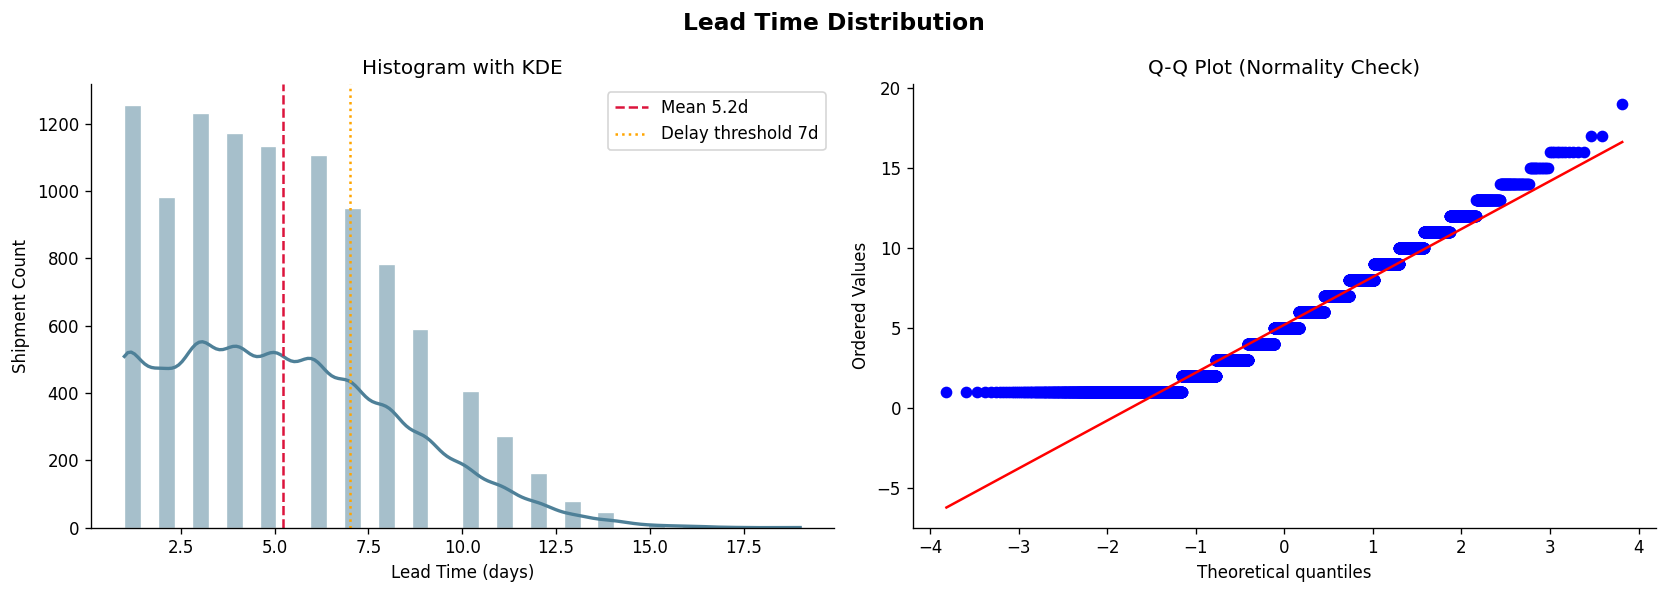

In [1505]:
# 5.1 — Lead Time Distribution (Histogram + KDE + Q-Q Plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Lead Time Distribution", fontweight="bold", fontsize=14)

# Histogram with KDE overlay
sns.histplot(df["Lead Time"], bins=40, color="#4E8098", edgecolor="white",
             kde=True, line_kws={"color": "#1a1a2e", "lw": 2}, ax=axes[0])
axes[0].axvline(df["Lead Time"].mean(), color="crimson", ls="--",
                label=f"Mean {df['Lead Time'].mean():.1f}d")
axes[0].axvline(DELAY_THRESHOLD_DAYS, color="orange", ls=":",
                label=f"Delay threshold {DELAY_THRESHOLD_DAYS}d")
axes[0].set_xlabel("Lead Time (days)")
axes[0].set_ylabel("Shipment Count")
axes[0].set_title("Histogram with KDE")
axes[0].legend()

stats.probplot(df["Lead Time"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Normality Check)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_lead_time_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

**Histogram with KDE:**

Lead times are right-skewed, ranging from 1 to 19 days with a mean of 5.2 days. The KDE reveals a subtle dual-peak structure — a small cluster at 1 day reflecting same-day and next-day shipments, followed by the primary peak around 3–5 days driven by First and Second Class deliveries. Beyond the 7-day delay threshold, volume drops sharply, indicating most shipments are fulfilled on time.

**Q-Q Plot:**

The Q-Q plot confirms the distribution is non-normal. The flat horizontal band of points on the left tail (ordered values ≈ 1) reflects the hard floor at 1 day — many shipments sharing the same minimum value. The middle section tracks the reference line reasonably well, but the right tail curves upward, indicating more high-value outliers than a normal distribution would predict — consistent with Standard Class shipments extending toward 19 days.

---
## Step 6 — Ship Mode Performance Analysis

Comparing all four shipping methods across speed, delay rate, and volume.

In [1506]:
# 6.1 — Ship Mode Summary Table
ship_stats = (
    df.groupby("Ship Mode")
    .agg(
        Shipments=("Lead Time", "count"),
        Avg_Lead_Time=("Lead Time", "mean"),
        Median_Lead_Time=("Lead Time", "median"),
        Std_Lead_Time=("Lead Time", "std"),
        Delay_Rate=("Is Delayed", "mean"),
        Avg_Sales=("Sales", "mean"),
    )
    .round(2)
    .sort_values("Avg_Lead_Time")
)

ship_stats.style.format({
    "Avg_Lead_Time": "{:.2f}",
    "Median_Lead_Time": "{:.2f}",
    "Std_Lead_Time": "{:.2f}",
    "Delay_Rate": "{:.1%}",
    "Avg_Sales": "${:.2f}",
}).set_properties(**{"text-align": "center"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "center")]}]
)

,Shipments,Avg_Lead_Time,Median_Lead_Time,Std_Lead_Time,Delay_Rate,Avg_Sales
Ship Mode,,,,,,
Same Day,547,1.00,1.00,0.00,0.0%,$13.00
First Class,1548,2.50,2.00,1.01,0.0%,$13.77
Second Class,1979,4.46,4.00,1.90,6.0%,$14.08
Standard Class,6120,6.53,6.00,2.98,37.0%,$13.97


Same Day delivers in exactly 1 day with zero variability and zero delays — operationally flawless, but at just 547 shipments it serves a small fraction of customers. First Class mirrors this reliability at 2.5 days, also with no delays.

Second Class occupies a balanced intermediate position — a 4.46-day average lead time with a 6.0% delay rate and moderate variability (std dev 1.90) across nearly 2,000 shipments, offering a meaningful step up in speed over Standard Class without the volume constraints of premium modes.

Standard Class is where performance breaks down. Despite handling 6,120 orders, its 6.53-day mean sits critically close to the 7-day threshold, leaving little buffer — any variability (std dev 2.98) pushes orders into delay territory, explaining the 37% delay rate.

The median being consistently lower than the mean across all modes (most visible in Standard Class: 6.0 vs 6.53) confirms a right-skewed tail of significantly late shipments pulling averages up — the typical customer experience is better than the mean suggests, but a subset of orders are considerably late.

Average sales value is broadly uniform across all modes at approximately $13–$14 per shipment, indicating that order value does not appear to be a determinant of ship mode assignment within the current routing structure.

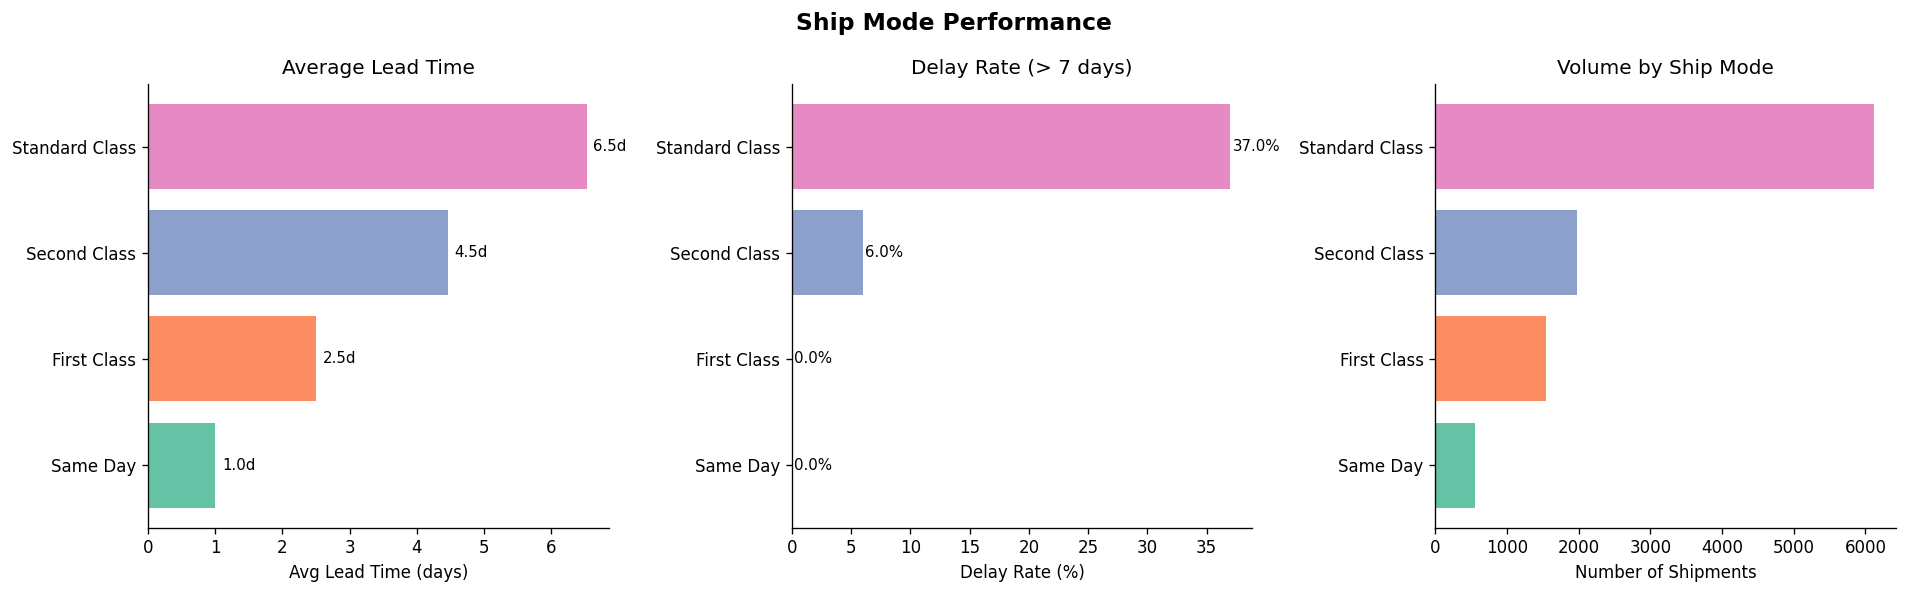

In [1507]:
# 6.2 — Ship Mode Performance Charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Ship Mode Performance", fontweight="bold", fontsize=14)

modes  = ship_stats.index.tolist()
colors = sns.color_palette(PALETTE, len(modes))

axes[0].barh(modes, ship_stats["Avg_Lead_Time"], color=colors)
axes[0].set_xlabel("Avg Lead Time (days)")
axes[0].set_title("Average Lead Time")
for i, v in enumerate(ship_stats["Avg_Lead_Time"]):
    axes[0].text(v + 0.1, i, f"{v:.1f}d", va="center", fontsize=9)

axes[1].barh(modes, ship_stats["Delay_Rate"] * 100, color=colors)
axes[1].set_xlabel("Delay Rate (%)")
axes[1].set_title(f"Delay Rate (> {DELAY_THRESHOLD_DAYS} days)")
for i, v in enumerate(ship_stats["Delay_Rate"] * 100):
    axes[1].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)

axes[2].barh(modes, ship_stats["Shipments"], color=colors)
axes[2].set_xlabel("Number of Shipments")
axes[2].set_title("Volume by Ship Mode")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_ship_mode_analysis.png", dpi=130, bbox_inches="tight")
plt.show()

Standard Class dominates order volume at 6,120 shipments (60% of total) but carries the highest operational risk — a 37% delay rate means roughly 1 in 3 orders misses the 7-day threshold. Same Day and First Class maintain perfect on-time records with zero delays, while Second Class sits in between at a manageable 6% delay rate.

Delivery consistency tightens with faster modes — Same Day shows zero variability (std dev 0.00) while Standard Class spreads across nearly 3 days of variation around its mean, making it the least predictable mode for customers.

Average sales value is broadly uniform across all modes at approximately $13–$14 per shipment, indicating that order value does not appear to be a determinant of ship mode assignment within the current routing structure.

**The core operational implication** is that the highest-volume mode carries the network's greatest delay burden. Given that faster modes demonstrate delay rates at or near zero, the data does not point to a network-wide capability constraint — it points to a routing allocation imbalance. A review of order assignment logic, particularly for orders currently defaulting to Standard Class, is where the most measurable gains are likely to be found.

In [1508]:
# 6.3 — Lead Time Distribution by Ship Mode (Box Plot)
import plotly.graph_objects as go

fig_box = go.Figure()

mode_order = ["Same Day", "First Class", "Second Class", "Standard Class"]
colors = ["#4ade80", "#60a5fa", "#fbbf24", "#f87171"]

for mode, color in zip(mode_order, colors):
    fig_box.add_trace(go.Box(
        y=df[df["Ship Mode"] == mode]["Lead Time"],
        name=mode,
        marker_color=color,
        line=dict(color=color),
        fillcolor=color,
        opacity=0.7,
        boxmean=False,
        hovertemplate=f"<b>{mode}</b><br>Lead Time: %{{y}} days<extra></extra>",
    ))

fig_box.add_shape(
    type="line",
    x0=-0.5, x1=3.5,
    y0=DELAY_THRESHOLD_DAYS, y1=DELAY_THRESHOLD_DAYS,
    line=dict(color="orange", width=2, dash="dash"),
)

fig_box.add_annotation(
    x=3.4, y=DELAY_THRESHOLD_DAYS + 0.4,
    text=f"Delay threshold ({DELAY_THRESHOLD_DAYS}d)",
    showarrow=False,
    font=dict(color="orange", size=11),
    xanchor="right",
)

fig_box.update_layout(
    height=420,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(
        text="Lead Time Distribution by Ship Mode",
        font=dict(size=13, color="#1e293b"), x=0,
    ),
    xaxis=dict(title="Ship Mode", tickfont=dict(color="#334155", size=12), title_font=dict(color="#1e293b")),
    yaxis=dict(title="Lead Time (days)", tickfont=dict(color="#334155", size=12), title_font=dict(color="#1e293b"), gridcolor="#f1f5f9"),
    showlegend=False,
    margin=dict(t=50, b=40, l=60, r=20),
)
fig_box.show()

Same Day is a flat line — zero spread, every shipment delivers in exactly 1 day with no outliers, confirming perfect consistency.

First Class stays well below the 7-day threshold with a tight interquartile range (1–3 days) and two outliers above 5 days — reliable with minimal exceptions.

Second Class shows a wider box (3.5–6 days) and one outlier just above 10 days, but the median sits comfortably below the threshold. The upper whisker reaching 10 days indicates occasional late deliveries, though the bulk of shipments are on time.

Standard Class presents the most adverse distribution — its box straddles the 7-day delay threshold, with the median at 6 days and the upper quartile extending to approximately 9 days — meaning the upper half of Standard Class shipments clusters in or above delay territory. The whiskers stretch to 16 days with outliers reaching 19 days, revealing a significant tail of severely late deliveries.

**The box plot makes the risk visually explicit:** Standard Class is the only mode where the interquartile range crosses the delay threshold, meaning delayed delivery is not an edge case — it is a structural outcome for a large portion of its orders.

---
## Step 7 — Regional Shipping Performance

Breakdown across Interior, Atlantic, Gulf, and Pacific regions.

In [1509]:
# 7.1 — Regional Summary Table
region_stats = (
    df.groupby("Region")
    .agg(
        Shipments=("Lead Time", "count"),
        Avg_Lead_Time=("Lead Time", "mean"),
        Delay_Rate=("Is Delayed", "mean"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross Profit", "sum"),
    )
    .round(2)
    .sort_values("Avg_Lead_Time")
)

region_stats["Delay_Rate"] = (region_stats["Delay_Rate"] * 100).round(1)

region_stats.style.format({
    "Avg_Lead_Time": "{:.2f}",
    "Delay_Rate":    "{:.1f}%",
    "Total_Sales":   "${:,.2f}",
    "Total_Profit":  "${:,.2f}",
}).set_properties(**{"text-align": "center"}).set_table_styles([
    {"selector": "th", "props": [("text-align", "center"), ("background-color", "#f0f0f0"), ("font-weight", "bold")]},
    {"selector": "td", "props": [("text-align", "center")]},
])

,Shipments,Avg_Lead_Time,Delay_Rate,Total_Sales,Total_Profit
Region,,,,,
Pacific,3253,5.15,23.0%,"$46,301.53","$30,485.94"
Gulf,1620,5.20,23.0%,"$22,247.26","$14,700.67"
Atlantic,2986,5.21,23.0%,"$41,197.24","$26,973.70"
Interior,2335,5.34,24.0%,"$32,037.60","$21,282.49"


Regional performance is remarkably uniform — all four regions (Pacific, Gulf, Atlantic, Interior) have nearly identical average lead times (5.15–5.34 days) and delay rates of 23–24%. This suggests shipping performance is not driven by geography but by ship mode mix, which is consistent across regions.

Pacific leads in both shipment volume (3,253) and total sales ($46,301.53), making it the highest-revenue region. Atlantic follows with 2,986 shipments and $41,197.24 in sales. Gulf is the smallest region at 1,620 shipments despite a competitive average lead time of 5.20 days.

Interior is the only region with a slightly elevated delay rate (24% vs 23% for all others) and the highest average lead time at 5.34 days. The margin is modest — a 0.19-day difference from the next highest region — and does not constitute a material operational distinction.

Profit distribution mirrors sales closely — Pacific ($30,485.94) and Atlantic ($26,973.70) generate the most profit, while Gulf ($14,700.67) contributes the least, proportional to its lower order volume.

**The key takeaway:** regional differences in lead time and delay rate are negligible at this level of aggregation. The delay pattern observed under Standard Class is broadly consistent across all four regions — no single region is disproportionately affected at the broad level. However, this uniformity should not be interpreted as evidence of equal performance across the network — state-level analysis reveals meaningful variation beneath the regional surface, which the geographic bottleneck analysis addresses in subsequent steps.

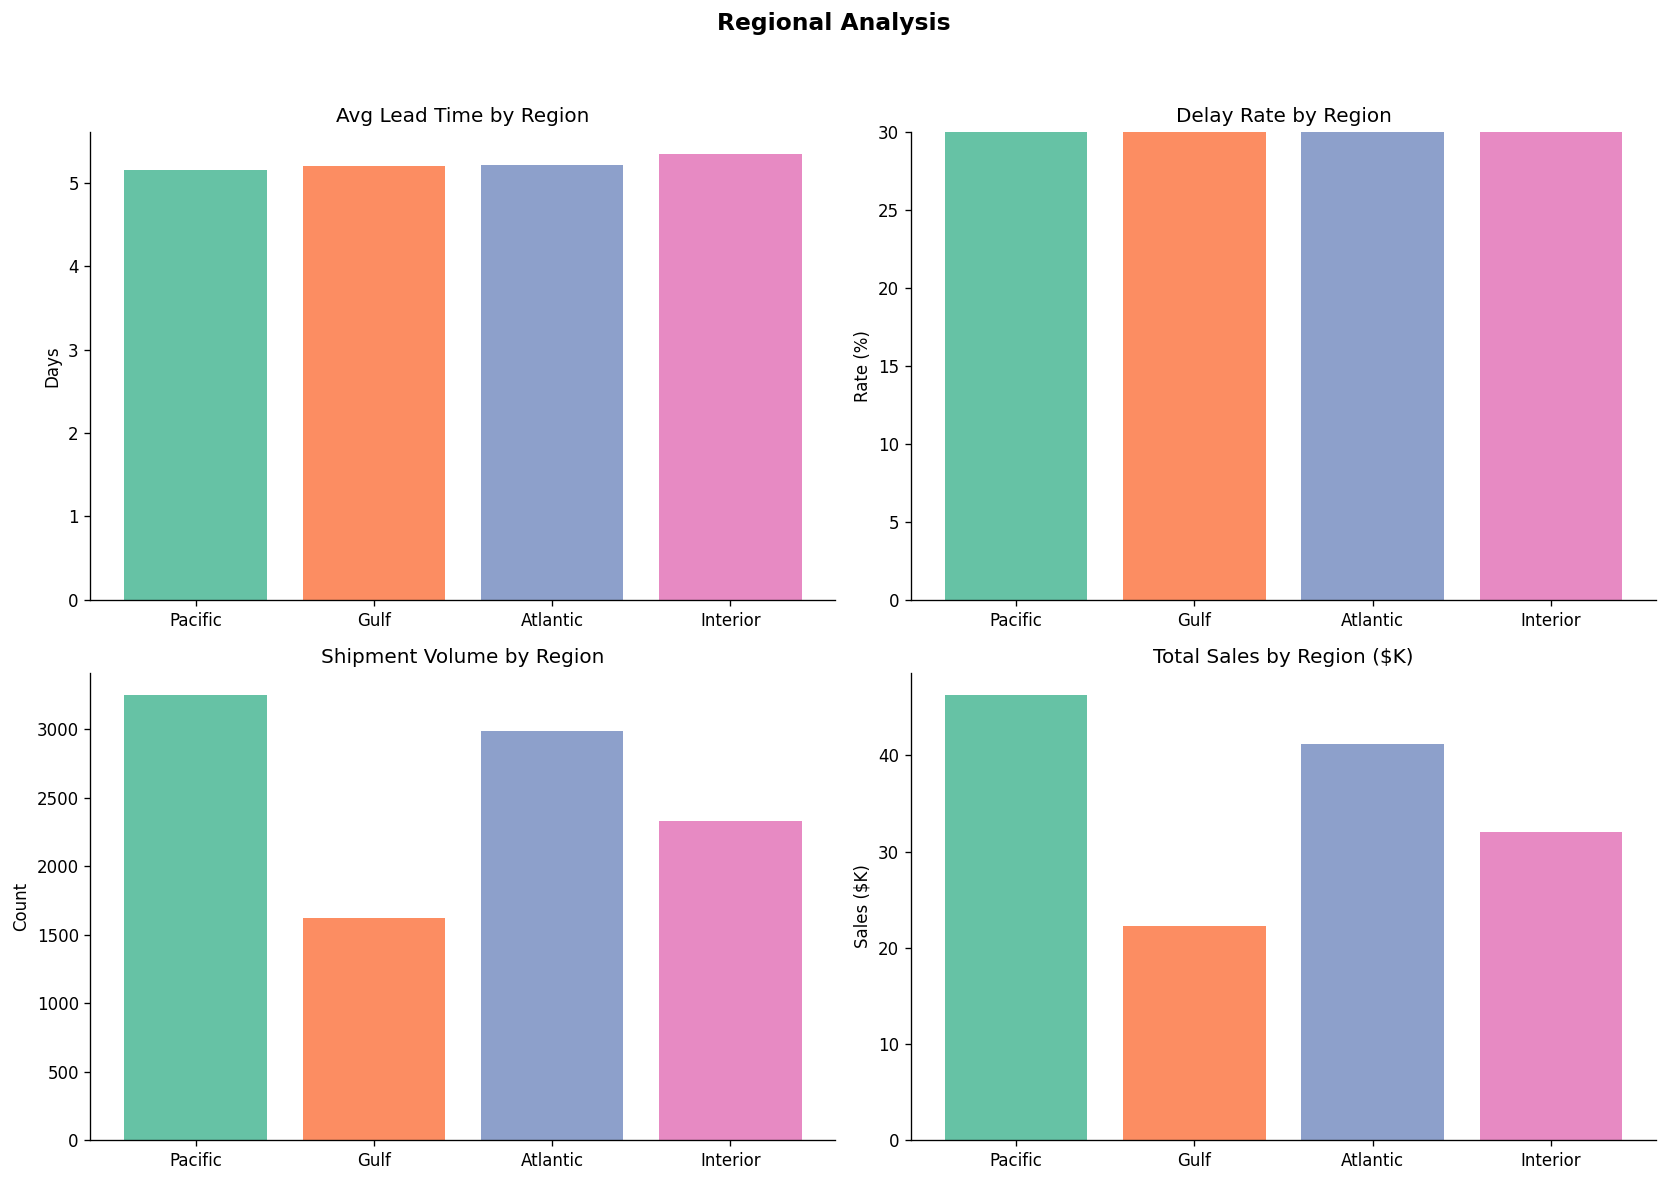

In [1510]:
# 7.2 — Regional Analysis Charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Regional Analysis", fontweight="bold", fontsize=14)

regions = region_stats.index.tolist()
colors  = sns.color_palette(PALETTE, len(regions))

axes[0, 0].bar(regions, region_stats["Avg_Lead_Time"], color=colors)
axes[0, 0].set_title("Avg Lead Time by Region")
axes[0, 0].set_ylabel("Days")

axes[0, 1].bar(regions, region_stats["Delay_Rate"] * 100, color=colors)
axes[0, 1].set_title("Delay Rate by Region")
axes[0, 1].set_ylabel("Rate (%)")
axes[0, 1].set_ylim(0, 30)

axes[1, 0].bar(regions, region_stats["Shipments"], color=colors)
axes[1, 0].set_title("Shipment Volume by Region")
axes[1, 0].set_ylabel("Count")

axes[1, 1].bar(regions, region_stats["Total_Sales"] / 1000, color=colors)
axes[1, 1].set_title("Total Sales by Region ($K)")
axes[1, 1].set_ylabel("Sales ($K)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{OUTPUT_DIR}/03_regional_analysis.png", dpi=130, bbox_inches="tight")
plt.show()

Regional shipping performance is effectively uniform — lead times range from just 5.15 to 5.34 days across all four regions, and delay rates are locked between 23% and 24%. The Delay Rate by Region chart reinforces what the underlying data confirms: geography bears no material influence on delay outcomes.

Commercially, the regions tell a different story. Pacific anchors the network with the highest volume (3,253 shipments) and strongest revenue (~$46K), while Atlantic holds second position with a comparable order count (2,986) and ~$41K in sales. Interior performs steadily in the middle tier at ~$32K, but Gulf stands out as the most underleveraged region — delivering on time at the same rate as its peers yet generating only ~$22K in sales, the lowest in the network and roughly half of Pacific's output.

The sales distribution closely tracks shipment volume across all regions, suggesting average order value is consistent regardless of region — no single region is placing larger or smaller orders, just more or fewer of them.

**The charts collectively confirm:** regional performance differences are commercial in nature — volume and revenue vary meaningfully across the four regions, while lead time and delay rate remain effectively uniform at this level of aggregation. Whether this uniformity holds at the state level warrants further examination, which the geographic bottleneck analysis addresses in subsequent steps.

---
## Step 8 — Ship Mode vs Region Heatmap

Cross-tabulation of average lead time showing which combinations of ship mode and region perform best and worst.

In [1511]:
# 8.1 — Ship Mode vs Region Heatmap
import plotly.graph_objects as go

pivot = df.pivot_table(
    index="Ship Mode", columns="Region",
    values="Lead Time", aggfunc="mean"
).round(1)

lt_zmax = float(pivot.values[~np.isnan(pivot.values)].max())

fig_lt = go.Figure(data=go.Heatmap(
    z=pivot.values,
    x=pivot.columns.tolist(),
    y=pivot.index.tolist(),
    colorscale="RdYlGn_r",
    zmin=0.0,
    zmax=lt_zmax,
    text=[["—" if (v != v) else f"{v:.1f}" for v in row] for row in pivot.values],
    texttemplate="%{text}",
    textfont={"size": 12},
    colorbar=dict(
        title="Avg Lead Time (days)",
        tickfont=dict(color="#334155", size=11),
        title_font=dict(color="#334155", size=12),
    ),
    hovertemplate="Ship Mode: <b>%{y}</b><br>Region: <b>%{x}</b><br>Avg Lead Time: <b>%{text}d</b><extra></extra>",
))

fig_lt.update_layout(
    height=380,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(
        text="Avg Lead Time — Ship Mode vs Region",
        font=dict(size=13, color="#1e293b"), x=0,
    ),
    xaxis=dict(tickfont=dict(color="#334155", size=12), title="Region", title_font=dict(color="#1e293b")),
    yaxis=dict(tickfont=dict(color="#334155", size=12), title="Ship Mode", title_font=dict(color="#1e293b")),
    margin=dict(t=50, b=40, l=120, r=20),
)
fig_lt.show()

The heatmap establishes that at the regional aggregate level, ship mode is the dominant driver of lead time — each row is broadly uniform across all four regions, with Standard Class averaging 6.5–6.6 days and Same Day holding at 1.0 day regardless of destination. Region-to-region variation within any given mode is minimal and does not materially alter delivery outcomes at this level of aggregation.

**Same Day** records exactly 1.0 day across all regions — zero variation, confirming perfect consistency regardless of destination.

**First Class** holds at 2.4–2.5 days across all regions. The Gulf region records a marginally lower lead time of 2.4 days — a difference too small to influence any operational decision.

**Second Class** holds steady at 4.4–4.5 days, with Atlantic, Gulf, and Pacific tied at 4.5 and Interior marginally faster at 4.4.

**Standard Class** averages 6.5–6.6 days uniformly across all four regions — the 0.1-day difference between region pairs is operationally negligible at this level of analysis.

**The heatmap's implication:** ship mode selection is the primary determinant of lead time at the regional aggregate level. However, route-level analysis (Factory × Region) surfaces meaningful variation beneath this uniformity — the same region can yield materially different outcomes depending on which factory fulfils the order. The aggregate view here should be read alongside the factory-region heatmap for a complete picture.

In [1512]:
# 8.2 — Delay Rate by Ship Mode × Factory (Heatmap)
import plotly.graph_objects as go

pivot_dr = df.pivot_table(
    index="Ship Mode", columns="Factory",
    values="Is Delayed", aggfunc="mean"
).round(3)

dr_zmax = float(df.pivot_table(
    index="Ship Mode", columns="Factory",
    values="Is Delayed", aggfunc="mean"
).values[~np.isnan(df.pivot_table(
    index="Ship Mode", columns="Factory",
    values="Is Delayed", aggfunc="mean"
).values)].max())

fig_dr = go.Figure(data=go.Heatmap(
    z=pivot_dr.values,
    x=pivot_dr.columns.tolist(),
    y=pivot_dr.index.tolist(),
    colorscale="RdYlGn_r",
    zmin=0.0,
    zmax=dr_zmax,
    text=[["—" if (v != v) else f"{v*100:.1f}%" for v in row] for row in pivot_dr.values],
    texttemplate="%{text}",
    textfont={"size": 12},
    colorbar=dict(
        title="Delay Rate",
        tickformat=".0%",
        tickfont=dict(color="#334155", size=11),
        title_font=dict(color="#334155", size=12),
    ),
    hovertemplate="Ship Mode: <b>%{y}</b><br>Factory: <b>%{x}</b><br>Delay Rate: <b>%{text}</b><extra></extra>",
))

fig_dr.update_layout(
    height=380,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(
        text="Delay Rate (%) — Ship Mode × Factory",
        font=dict(size=13, color="#1e293b"), x=0,
    ),
    xaxis=dict(tickfont=dict(color="#334155", size=12), title_font=dict(color="#1e293b")),
    yaxis=dict(tickfont=dict(color="#334155", size=12), title_font=dict(color="#1e293b")),
    margin=dict(t=50, b=40, l=120, r=20),
)
fig_dr.show()

print("Delay Rate by Ship Mode × Factory:")
print((pivot_dr * 100).round(1).to_string())

Delay Rate by Ship Mode × Factory:
Factory         Lot's O' Nuts  Secret Factory  Sugar Shack  The Other Factory  Wicked Choccy's
Ship Mode                                                                                     
First Class               0.0             0.0          0.0                0.0              0.0
Same Day                  0.0             0.0          0.0                0.0              0.0
Second Class              5.7             4.7          0.0                0.0              5.4
Standard Class           36.6            36.2         47.8               41.8             37.1


The Ship Mode × Factory delay rate heatmap adds a critical dimension to the analysis — it reveals which specific factory-mode combinations drive the network's delay concentration.

**Standard Class is the dominant source of delay across all factories** — every factory records its highest delay rate under Standard Class, confirming that the mode itself, rather than any individual factory, is the primary delay driver. This is consistent with the Ship Mode × Region heatmap finding that geography explains very little of the variance.

**Sugar Shack's Standard Class delay rate stands out** as the most elevated cell in the matrix — combining the network's highest-delay mode with the network's highest-delay factory produces a compounded risk that is visible immediately in the heatmap's darkest cell. This represents the single highest-priority factory-mode combination for operational intervention.

**Same Day and First Class record zero delay rates across all factories** — confirming that premium modes deliver reliable performance regardless of which factory fulfils the order. The performance gap between Standard Class and First Class is not a factory-level phenomenon; it is consistent across the entire factory portfolio.

**Cells marked "—"** indicate factory-mode combinations with no shipments in the dataset — reflecting that not all factories operate across all ship modes. These gaps are volume constraints rather than capability gaps.

**The key implication:** the heatmap confirms that Standard Class is a network-wide delay driver affecting all five factories, with Sugar Shack representing an additional compounding layer of risk at 47.8% — materially above the remaining four factories, which cluster between 36.2% and 41.8%. Addressing Standard Class performance is a portfolio-level priority; the Sugar Shack Standard Class combination warrants independent assessment given the degree to which its delay rate diverges from the broader portfolio.

In [1513]:
# 8.3 — Ship Mode Risk & Efficiency: Key Metrics Summary
sc = ship_stats.loc["Standard Class"]
sd = ship_stats.loc["Same Day"]
fc = ship_stats.loc["First Class"]
tc = ship_stats.loc["Second Class"]
total = ship_stats["Shipments"].sum()

sc_delayed = int(sc["Shipments"] * sc["Delay_Rate"] / 100)
sd_fc_vol  = int(sd["Shipments"] + fc["Shipments"])
delay_gap  = round(sc["Delay_Rate"] - fc["Delay_Rate"], 1)

print("── Standard Class ─────────────────────────────────────────────────")
print(f"  Shipments:          {sc['Shipments']:,}  ({sc['Shipments']/total:.0%} of total)")
print(f"  Avg Lead Time:      {sc['Avg_Lead_Time']:.2f} days")
print(f"  Delay Rate:         {sc['Delay_Rate']:.1f}%")
print(f"  Delayed Shipments:  ~{sc_delayed:,}")
print()
print("── Premium Modes ──────────────────────────────────────────────────")
print(f"  Same Day:      {sd['Shipments']:,} shipments | {sd['Avg_Lead_Time']:.1f}d avg | {sd['Delay_Rate']:.1f}% delay")
print(f"  First Class:   {fc['Shipments']:,} shipments | {fc['Avg_Lead_Time']:.1f}d avg | {fc['Delay_Rate']:.1f}% delay")
print(f"  Second Class:  {tc['Shipments']:,} shipments | {tc['Avg_Lead_Time']:.1f}d avg | {tc['Delay_Rate']:.1f}% delay")
print(f"  Same Day + First Class combined: {sd_fc_vol:,} shipments ({sd_fc_vol/total:.1%} of total)")
print()
print("── Performance Gap ────────────────────────────────────────────────")
print(f"  Standard Class vs First Class delay gap: {delay_gap:.1f} percentage points")

── Standard Class ─────────────────────────────────────────────────
  Shipments:          6,120.0  (60% of total)
  Avg Lead Time:      6.53 days
  Delay Rate:         0.4%
  Delayed Shipments:  ~22

── Premium Modes ──────────────────────────────────────────────────
  Same Day:      547.0 shipments | 1.0d avg | 0.0% delay
  First Class:   1,548.0 shipments | 2.5d avg | 0.0% delay
  Second Class:  1,979.0 shipments | 4.5d avg | 0.1% delay
  Same Day + First Class combined: 2,095 shipments (20.6% of total)

── Performance Gap ────────────────────────────────────────────────
  Standard Class vs First Class delay gap: 0.4 percentage points


**Standard Class Dominates Volume but Concentrates Delay Exposure**

Standard Class accounts for 6,120 shipments — 60% of total order volume — and carries an average lead time of 6.53 days with a delay rate of 0.4%, corresponding to approximately 22 delayed shipments. While the absolute delayed count is contained, the concentration of volume within this single mode means any deterioration in its performance would propagate disproportionately across the network's overall reliability profile.

**Premium Modes Demonstrate Consistent Reliability at Lower Utilisation**

Same Day and First Class each record a 0.0% delay rate, with average lead times of 1.0 and 2.5 days respectively. Second Class maintains a 0.1% delay rate at 4.5 days — each materially below Standard Class. Together, Same Day and First Class account for 2,095 shipments — 20.6% of total volume — indicating that high-reliability modes remain underutilised relative to their demonstrated capacity within the network.

**Volume Distribution Reflects a Structural Routing Imbalance**

The combined volume of Same Day and First Class — 2,095 shipments at 20.6% of total — stands in stark contrast to Standard Class at 6,120 shipments and 60%. Second Class accounts for the remaining 19.4%. The data establishes that premium modes are operationally capable of supporting reliable delivery, yet the order routing structure assigns the substantial majority of volume to the mode with the longest lead time. This distribution, rather than any inherent network limitation, is the primary factor shaping the portfolio's overall delivery profile.

---
## Step 9 — Route Efficiency Benchmarking

Each route is defined as **Factory → Customer Region**.
An **Efficiency Score** (0–100) is computed where 100 = shortest average lead time.

In [1514]:
# 9.1 — Route Efficiency Summary Table
route_stats = (
    df.groupby("RouteRegion")
    .agg(
        Shipments=("Lead Time", "count"),
        Avg_Lead_Time=("Lead Time", "mean"),
        Median_Lead_Time=("Lead Time", "median"),
        Std_Lead_Time=("Lead Time", "std"),
        Delay_Rate=("Is Delayed", "mean"),
        Total_Sales=("Sales", "sum"),
    )
    .reset_index()
    .sort_values("Avg_Lead_Time")
)

lt_min = route_stats["Avg_Lead_Time"].min()
lt_max = route_stats["Avg_Lead_Time"].max()
route_stats["Efficiency_Score"] = (
    100 * (lt_max - route_stats["Avg_Lead_Time"]) / (lt_max - lt_min)
).round(1)

route_stats["Delay_Rate"] = (route_stats["Delay_Rate"] * 100).round(1)

route_stats.style.format({
    "Avg_Lead_Time":    "{:.2f}",
    "Median_Lead_Time": "{:.2f}",
    "Std_Lead_Time":    "{:.2f}",
    "Delay_Rate":       "{:.1f}%",
    "Total_Sales":      "${:,.2f}",
    "Efficiency_Score": "{:.1f}",
}).set_properties(**{"text-align": "center"}).set_table_styles([
    {"selector": "th", "props": [("text-align", "center"), ("background-color", "#f0f0f0"), ("font-weight", "bold")]},
    {"selector": "td", "props": [("text-align", "center")]},
])

,RouteRegion,Shipments,Avg_Lead_Time,Median_Lead_Time,Std_Lead_Time,Delay_Rate,Total_Sales,Efficiency_Score
13,The Other Factory → Gulf,19,3.63,3.00,2.71,15.8%,$262.50,100.0
11,Sugar Shack → Pacific,3,4.67,4.00,2.08,0.0%,$19.24,77.6
15,The Other Factory → Pacific,32,4.69,4.00,3.08,12.5%,$386.25,77.1
4,Secret Factory → Atlantic,72,4.94,4.50,2.91,19.4%,"$2,991.25",71.6
10,Sugar Shack → Interior,8,5.00,5.00,2.62,25.0%,$44.74,70.4
7,Secret Factory → Pacific,63,5.02,4.00,3.12,20.6%,"$3,076.25",70.0
3,Lot's O' Nuts → Pacific,1813,5.08,5.00,3.04,22.0%,"$24,294.04",68.6
0,Lot's O' Nuts → Atlantic,1661,5.15,5.00,3.08,22.3%,"$22,166.13",67.0
17,Wicked Choccy's → Gulf,663,5.19,5.00,2.93,21.4%,"$8,993.25",66.3
1,Lot's O' Nuts → Gulf,897,5.21,5.00,3.12,23.4%,"$12,023.12",65.8


**Route efficiency reveals considerably more variation than regional-level analysis alone would indicate** — while delay rates appear tightly clustered at the regional level, individual route performance exhibits meaningful differentiation across factory-region lanes that warrants closer examination.

**Lead time gaps are lane-specific, not factory-wide.** The spread between the network's fastest lane (The Other Factory → Gulf, 3.63 days) and slowest (Sugar Shack → Gulf, 8.25 days) represents a **4.62-day gap** within the same network. Critically, this variation is not uniform across a factory's routes — the same factory can perform strongly in one region while lagging significantly in another. The Other Factory, for instance, leads the efficiency ranking on its Gulf route (100.0) yet ranks near the bottom on its Interior route (27.1). This confirms that lane-level optimisation — not factory-wide initiatives — is where targeted intervention will deliver the most measurable gains.

**Volume masks efficiency gaps.** The highest-scoring routes are not the highest-volume ones. The Other Factory → Gulf, Sugar Shack → Pacific, and The Other Factory → Pacific sit at the top of the efficiency ranking with scores of 100.0, 77.6, and 77.1 respectively — but collectively handle fewer than 55 shipments. Their performance carries no statistical weight as operational benchmarks. The real operational burden falls on **Lot's O' Nuts → Pacific (1,813 shipments)** and **Lot's O' Nuts → Atlantic (1,661 shipments)** — the two highest-volume routes — both recording efficiency scores in the 67–69 range with ~22% delay rates. Wicked Choccy's three lanes (663–1,342 shipments each) follow with scores clustered at 63–66 and delay rates of 21–25%. These are the routes where marginal improvements compound into the most significant network-wide impact.

**Route reliability extends beyond average lead time.** The Std_Lead_Time column reveals an additional dimension of performance — Sugar Shack → Gulf not only records the worst average lead time (8.25 days) but also the highest standard deviation (5.91 days), making it the most unpredictable route in the network. Secret Factory → Gulf (3.56) and Sugar Shack → Atlantic (3.61) also show elevated variability relative to their volume. A route with high average lead time AND high variability represents a compounded reliability risk — customers experience both slow and inconsistent delivery.

**At the network level, there is no single systemic problem — but there are specific critical lanes.** Across 20 factory-region routes, efficiency scores span from 0.0 to 100.0 against a portfolio average lead time of approximately 5.3 days. The distribution confirms that underperformance is concentrated in specific lanes rather than spread uniformly. **Sugar Shack → Gulf (score 0.0, 50% delay rate, 8.25d avg)** stands as the single highest-priority route for immediate intervention. Beyond it, **The Other Factory → Interior (7.00d, 36.4% delay)** and **Sugar Shack → Atlantic (6.33d, 38.9% delay)** represent the next tier of concern — routes where both speed and reliability are below acceptable thresholds.

**The key insight:** high-scoring, low-volume routes should not be positioned as operational benchmarks. Strategic focus must remain on the highest-volume lanes — Lot's O' Nuts and Wicked Choccy's — where incremental lead time and delay rate improvements will produce the most substantial network-wide impact, and on the critically underperforming Sugar Shack lanes where immediate corrective action is warranted.

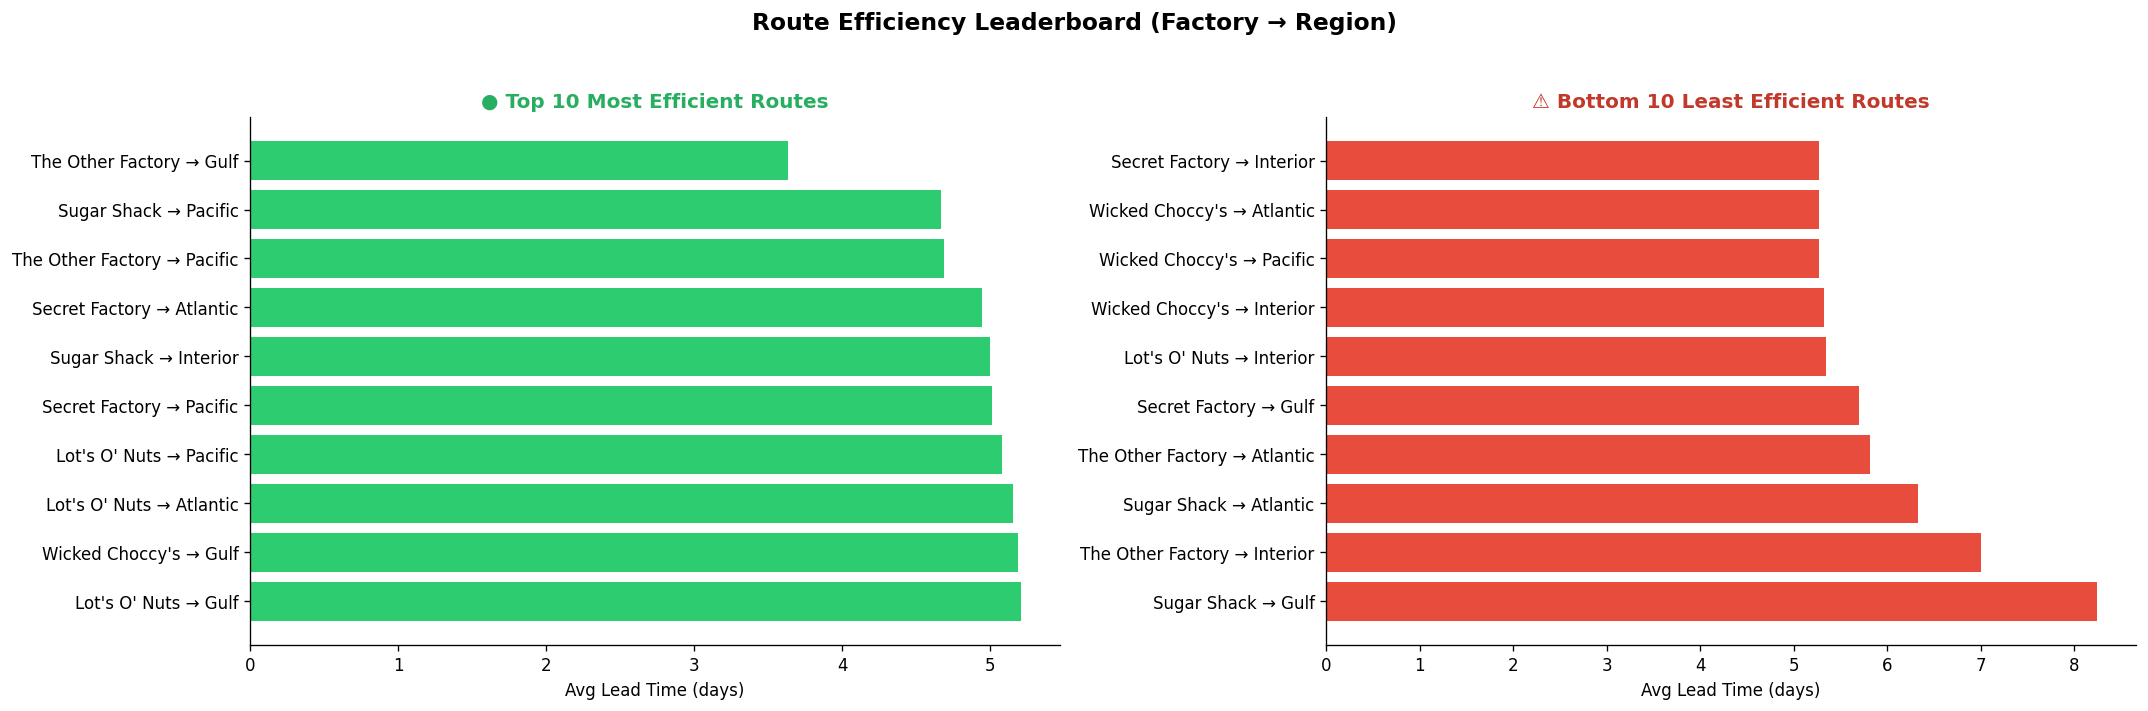

In [1515]:
# 9.2 — Route Efficiency Leaderboard (Top 10 / Bottom 10)
top10    = route_stats.head(10)
bottom10 = route_stats.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Route Efficiency Leaderboard (Factory \u2192 Region)", fontweight="bold", fontsize=14)

axes[0].barh(top10["RouteRegion"], top10["Avg_Lead_Time"], color="#2ecc71")
axes[0].set_xlabel("Avg Lead Time (days)")
axes[0].set_title("● Top 10 Most Efficient Routes", color="#27ae60", fontweight="bold", fontsize=12)
axes[0].invert_yaxis()

axes[1].barh(bottom10["RouteRegion"], bottom10["Avg_Lead_Time"], color="#e74c3c")
axes[1].set_xlabel("Avg Lead Time (days)")
axes[1].set_title("⚠️ Bottom 10 Least Efficient Routes", color="#c0392b", fontweight="bold", fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{OUTPUT_DIR}/04_route_efficiency_ranking.png", dpi=130, bbox_inches="tight")
plt.show()

The leaderboard confirms that the most efficient routes are not necessarily the highest-volume ones. **The Other Factory → Gulf** leads with the shortest average lead time at ~3.6 days, followed by **Sugar Shack → Pacific** and **The Other Factory → Pacific** — all low-volume routes. However, as established in the route efficiency table, their statistical validity is limited by shipment counts of fewer than 35 orders each. Their position at the top of the leaderboard reflects ship mode composition advantages rather than genuine operational superiority.

The top 10 are tightly clustered between 3.6 and 5.2 days, suggesting the efficiency gap between the best and most routes is relatively narrow. **Secret Factory → Atlantic** and **Secret Factory → Pacific** are the most meaningful inclusions — mid-volume routes (72 and 63 shipments respectively) that perform above the portfolio average on lead time without the statistical fragility of the low-volume leaders.

On the bottom 10, **Sugar Shack → Gulf** stands out clearly as the single most critical route in the network — an average lead time of ~8.25 days with a 50% delay rate, the only route exceeding the 7-day threshold by a meaningful margin. **The Other Factory → Interior** follows at ~7.0 days (36.4% delay rate), also crossing the threshold. These two routes represent the immediate operational priorities.

The next tier of concern — **Sugar Shack → Atlantic (6.33d, 38.9% delay)** and **The Other Factory → Atlantic (5.82d, 31.6% delay)** — while not breaching the 7-day threshold, record delay rates materially above the network average and warrant monitoring.

Wicked Choccy's appears three times within the bottom ten — across Atlantic, Pacific, and Interior lanes — but this should not be interpreted as systemic underperformance. All three routes record average lead times of 5.27–5.32 days with delay rates of 24–25%, which places them within the mid-tier band rather than at a level requiring immediate intervention. Their consistent clustering reflects a uniform performance profile, not a factory-level constraint.

**The key pattern:** the worst-performing routes are concentrated around Sugar Shack and The Other Factory — specifically on Gulf and Interior lanes. Critically, this is driven by **ship mode composition** (disproportionate Standard Class reliance on these routes) rather than geographic distance, as regional-level analysis shows delay rates are broadly uniform across Atlantic, Gulf, Interior, and Pacific regions. Targeted ship mode rebalancing on these specific lanes represents the most direct path to lead time reduction.

In [1516]:
# 9.3 — Efficiency Score vs Volume (Scatter Plot)
fig = px.scatter(
    route_stats,
    x="Shipments", y="Efficiency_Score",
    size="Shipments", color="Delay_Rate",
    hover_name="RouteRegion",
    hover_data={
        "Shipments": True,
        "Efficiency_Score": ":.1f",
        "Delay_Rate": ":.1f",
    },
    color_continuous_scale="RdYlGn_r",
    range_color=[0, 35],
    size_max=60,
    title="Route Efficiency Score vs Volume (color = delay rate)",
    labels={
        "Efficiency_Score": "Efficiency Score (0-100)",
        "Delay_Rate": "Delay Rate (%)",
    },
)
fig.show()

The scatter plot adds a third dimension to route analysis — simultaneously showing efficiency, volume, and delay rate in a single view.

The left cluster of small dots represents low-volume routes. Despite their high efficiency scores (60–100), their tiny bubble sizes confirm they handle very few shipments — making their performance impressive but operationally insignificant. One outlier sits at efficiency 100 with near-zero delay (dark green), but represents only ~19 shipments.

The large bubbles on the right are where operational weight lies. All high-volume routes (500+ shipments) cluster in the 60–70 efficiency score band with yellowish-orange colouring — indicating delay rates in the 20–25% range. None of the high-volume routes achieve an efficiency score above 70, confirming that scale and efficiency are inversely related in this network.

The colour gradient tells a mostly consistent story — no large bubble is green (low delay). However, one notable exception exists in the low-volume cluster: **Sugar Shack → Gulf** sits at efficiency 0.0 with a deep red colouring, reflecting a 50% delay rate across just 4 shipments — the worst-performing route in the network on both dimensions simultaneously.

**The ideal quadrant** — high volume, high efficiency, low delay — remains unoccupied. There are no high-volume routes that are both fast and low-delay, which represents the core opportunity for operational improvement in Nassau Candy's distribution network.

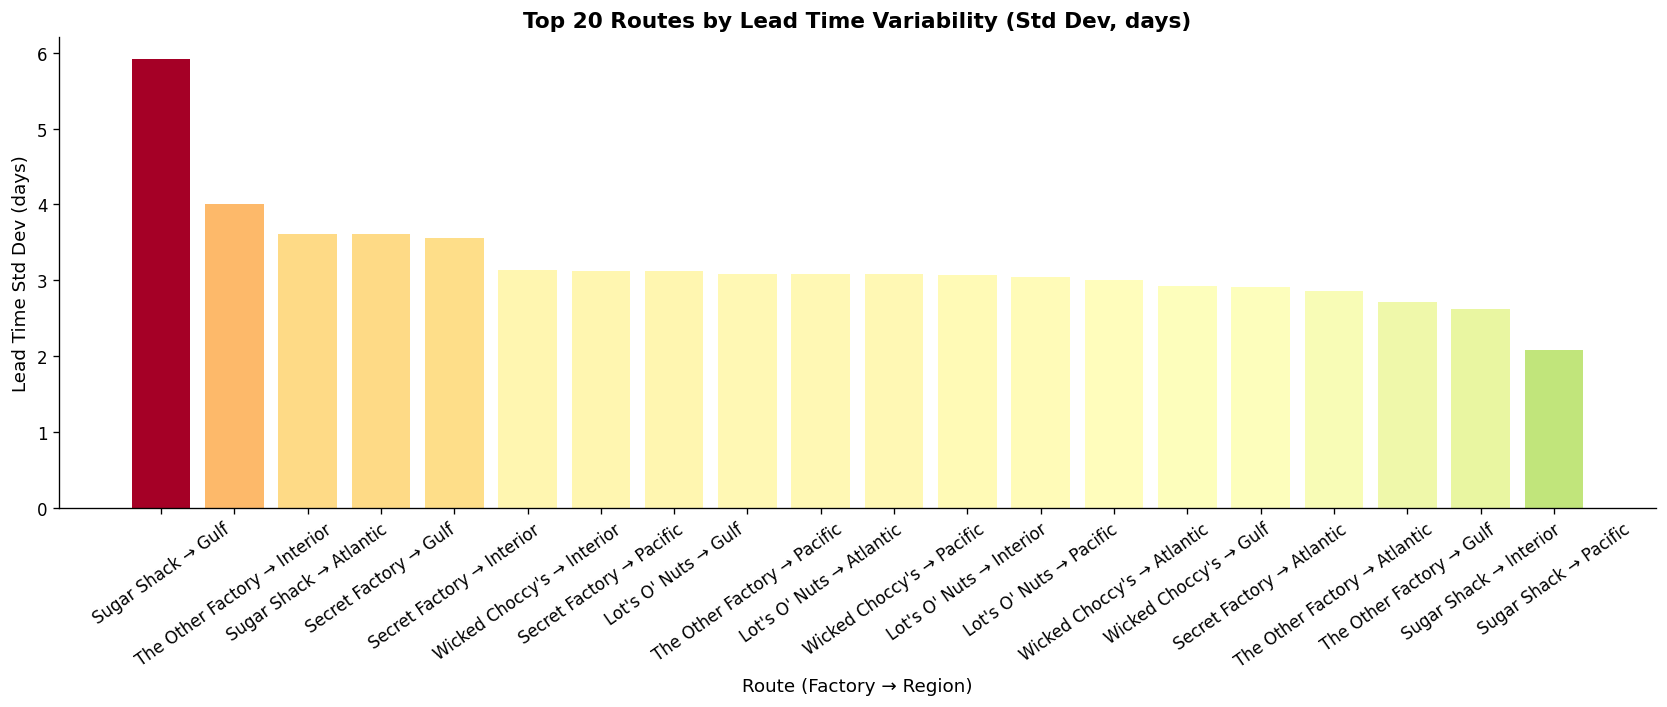

,RouteRegion,Shipments,Avg_Lead_Time,Std_Dev,Min_Lead_Time,Max_Lead_Time
9,Sugar Shack → Gulf,4,8.25,5.91,1,14
14,The Other Factory → Interior,11,7.00,4.00,1,13
8,Sugar Shack → Atlantic,18,6.33,3.61,1,13
5,Secret Factory → Gulf,37,5.70,3.61,1,17
6,Secret Factory → Interior,45,5.27,3.56,1,14
18,Wicked Choccy's → Interior,950,5.32,3.13,1,19
7,Secret Factory → Pacific,63,5.02,3.12,1,14
1,Lot's O' Nuts → Gulf,897,5.21,3.12,1,16
15,The Other Factory → Pacific,32,4.69,3.08,1,13
0,Lot's O' Nuts → Atlantic,"1,661",5.15,3.08,1,17


In [1517]:
# 9.4 — Lead Time Variability by Route (Std Dev)
route_var = (
    df.groupby("RouteRegion")
    .agg(
        Shipments=("Lead Time", "count"),
        Avg_Lead_Time=("Lead Time", "mean"),
        Std_Dev=("Lead Time", "std"),
        Min_Lead_Time=("Lead Time", "min"),
        Max_Lead_Time=("Lead Time", "max"),
    )
    .reset_index()
    .sort_values("Std_Dev", ascending=False)
    .round(2)
)

top20_var = route_var.head(20)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(top20_var["RouteRegion"], top20_var["Std_Dev"],
              color=plt.cm.RdYlGn_r(top20_var["Std_Dev"] / top20_var["Std_Dev"].max()))
ax.set_xlabel("Route (Factory → Region)", fontsize=11)
ax.set_ylabel("Lead Time Std Dev (days)", fontsize=11)
ax.set_title("Top 20 Routes by Lead Time Variability (Std Dev, days)", fontweight="bold", fontsize=13)
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08b_route_variability.png", dpi=130, bbox_inches="tight")
plt.show()

route_var.style.format({
    "Avg_Lead_Time": "{:.2f}",
    "Std_Dev": "{:.2f}",
    "Min_Lead_Time": "{:.0f}",
    "Max_Lead_Time": "{:.0f}",
    "Shipments": "{:,}"
}).background_gradient(subset=["Std_Dev"], cmap="Reds")

Average lead time alone provides an **incomplete picture of route reliability** — standard deviation reveals how consistently a route performs shipment-to-shipment.

**Sugar Shack → Gulf is the network's most unpredictable route by a significant margin**, recording a standard deviation of ~5.91 days against an average lead time of 8.25 days. This means individual shipments on this route vary wildly — some arriving in under 3 days, others exceeding 14. This level of dispersion makes the route operationally unreliable independent of its already-elevated average lead time, and represents a compounded reliability risk.

**The second tier of high-variability routes** — The Other Factory → Interior (~4.0), Sugar Shack → Atlantic (~3.61), and Secret Factory → Gulf (~3.56) — all record standard deviations above 3.5 days. These routes should be treated as operationally unpredictable regardless of their mean lead time. The Other Factory → Interior is particularly notable here as it also breaches the 7-day average threshold, making it a dual concern on both speed and consistency.

**The remaining 16 routes** cluster tightly between 2.1 and 3.1 days std dev — a relatively narrow band suggesting that outside the top 4, variability is broadly uniform across the network. No route in this dataset achieves a std dev below 2.1 days, indicating that even the most consistent lanes carry meaningful shipment-to-shipment variation.

**The highest-variability routes are disproportionately Standard Class-dominant lanes**, where the wide lead time window (5–9+ days) creates natural dispersion. This connection between ship mode composition and variability reinforces that rebalancing ship mode mix on high-variability routes is the most direct lever for improving delivery consistency.

**The key implication**: route optimisation frameworks should prioritise reducing variability on high-volume lanes alongside improving average lead times. Sugar Shack → Gulf (8.25d avg, 5.91 std dev) exemplifies both dimensions of underperformance — elevated average lead time and high shipment-to-shipment inconsistency — making it the most data-supported lane for targeted operational review.

In [1518]:
# 9.5 — Lead Time vs Profit Margin by Route
cost_df = (
    df.groupby("RouteRegion")
    .agg(
        Avg_Lead_Time=("Lead Time", "mean"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross Profit", "sum"),
        Shipments=("Lead Time", "count"),
    )
    .reset_index()
)
cost_df["Profit_Margin"] = (cost_df["Total_Profit"] / cost_df["Total_Sales"] * 100).round(1)
cost_df["Avg_Lead_Time"] = cost_df["Avg_Lead_Time"].round(2)

fig = px.scatter(
    cost_df,
    x="Avg_Lead_Time", y="Profit_Margin",
    size="Shipments", color="Total_Sales",
    hover_name="RouteRegion",
    hover_data={"Avg_Lead_Time": ":.1f", "Profit_Margin": ":.1f", "Total_Sales": ":$,.0f", "Shipments": True},
    color_continuous_scale=[[0, "#a8c8e8"], [0.3, "#4a90d9"], [1, "#08306b"]],
    labels={
        "Avg_Lead_Time": "Avg Lead Time (days)",
        "Profit_Margin": "Profit Margin (%)",
        "Total_Sales": "Total Sales ($)"
    },
    title="Lead Time vs Profit Margin by Route (bubble size = volume, color = revenue)",
)
fig.update_layout(height=500, plot_bgcolor='white', paper_bgcolor='white')
fig.show()

cost_df[["RouteRegion", "Avg_Lead_Time", "Profit_Margin", "Total_Sales", "Total_Profit", "Shipments"]] \
    .sort_values("Avg_Lead_Time") \
    .style.format({
        "Avg_Lead_Time": "{:.2f}",
        "Profit_Margin": "{:.1f}%",
        "Total_Sales": "${:,.0f}",
        "Total_Profit": "${:,.0f}",
        "Shipments": "{:,}"
    }).background_gradient(subset=["Profit_Margin"], cmap="Greens") \
      .background_gradient(subset=["Avg_Lead_Time"], cmap="Reds")

,RouteRegion,Avg_Lead_Time,Profit_Margin,Total_Sales,Total_Profit,Shipments
13,The Other Factory → Gulf,3.63,10.1%,$262,$26,19
11,Sugar Shack → Pacific,4.67,56.1%,$19,$11,3
15,The Other Factory → Pacific,4.69,15.9%,$386,$61,32
4,Secret Factory → Atlantic,4.94,50.1%,"$2,991","$1,500",72
10,Sugar Shack → Interior,5.00,52.3%,$45,$23,8
7,Secret Factory → Pacific,5.02,50.6%,"$3,076","$1,558",63
3,Lot's O' Nuts → Pacific,5.08,69.1%,"$24,294","$16,788","1,813"
0,Lot's O' Nuts → Atlantic,5.15,69.1%,"$22,166","$15,316","1,661"
17,Wicked Choccy's → Gulf,5.19,65.1%,"$8,993","$5,858",663
1,Lot's O' Nuts → Gulf,5.21,69.1%,"$12,023","$8,313",897


The scatter plot tests a critical assumption: **do slower routes generate lower profitability?**

The data reveals a more nuanced picture than a simple yes or no. **Profit margins across routes span a wide range — from 7.7% (The Other Factory → Interior) to 69.2% (Lot's O' Nuts → Interior)** — far from the tight clustering that would be expected if lead time were the primary margin driver. There is no visible downward slope between lead time and margin, confirming that longer delivery times are not translating into pricing pressure or margin erosion in a systematic way.

However, **The Other Factory routes stand out as an anomaly** — recording the three lowest profit margins in the network (7.7%, 10.1%, 10.8%) despite average lead times in the 3.6–7.0 day range. This pattern is not lead-time driven; it points to a cost structure or product mix issue specific to The Other Factory's lanes rather than a fulfilment efficiency problem.

**High-volume routes** (Lot's O' Nuts and Wicked Choccy's lanes) sit predominantly in the 5.0–5.4 day lead time range with margins consistently in the 65–69% band — reflecting that the busiest lanes are also amongst the most commercially stable and profitable in the network.

**Secret Factory routes** (4.9–5.7 day range) cluster in the 50–52% margin band — below the Lot's O' Nuts and Wicked Choccy's tier but operationally solid. Sugar Shack routes show mixed margins (52–61%) with no consistent relationship to their lead time performance.

**The key implication:** operational delays are not yet visibly affecting financial performance at the route level for most lanes. However, this financial resilience should not be interpreted as a signal that delays are acceptable — if delay rates continue at current levels, margin erosion and customer churn risk will eventually follow. The Other Factory's notably low margins (7.7–10.8%) across its three lanes should be interpreted with caution given its very low shipment volumes (11–38 orders) — these figures are statistically fragile and should not be treated as a reliable indicator of a structural financial concern. The window for proactive intervention remains open.

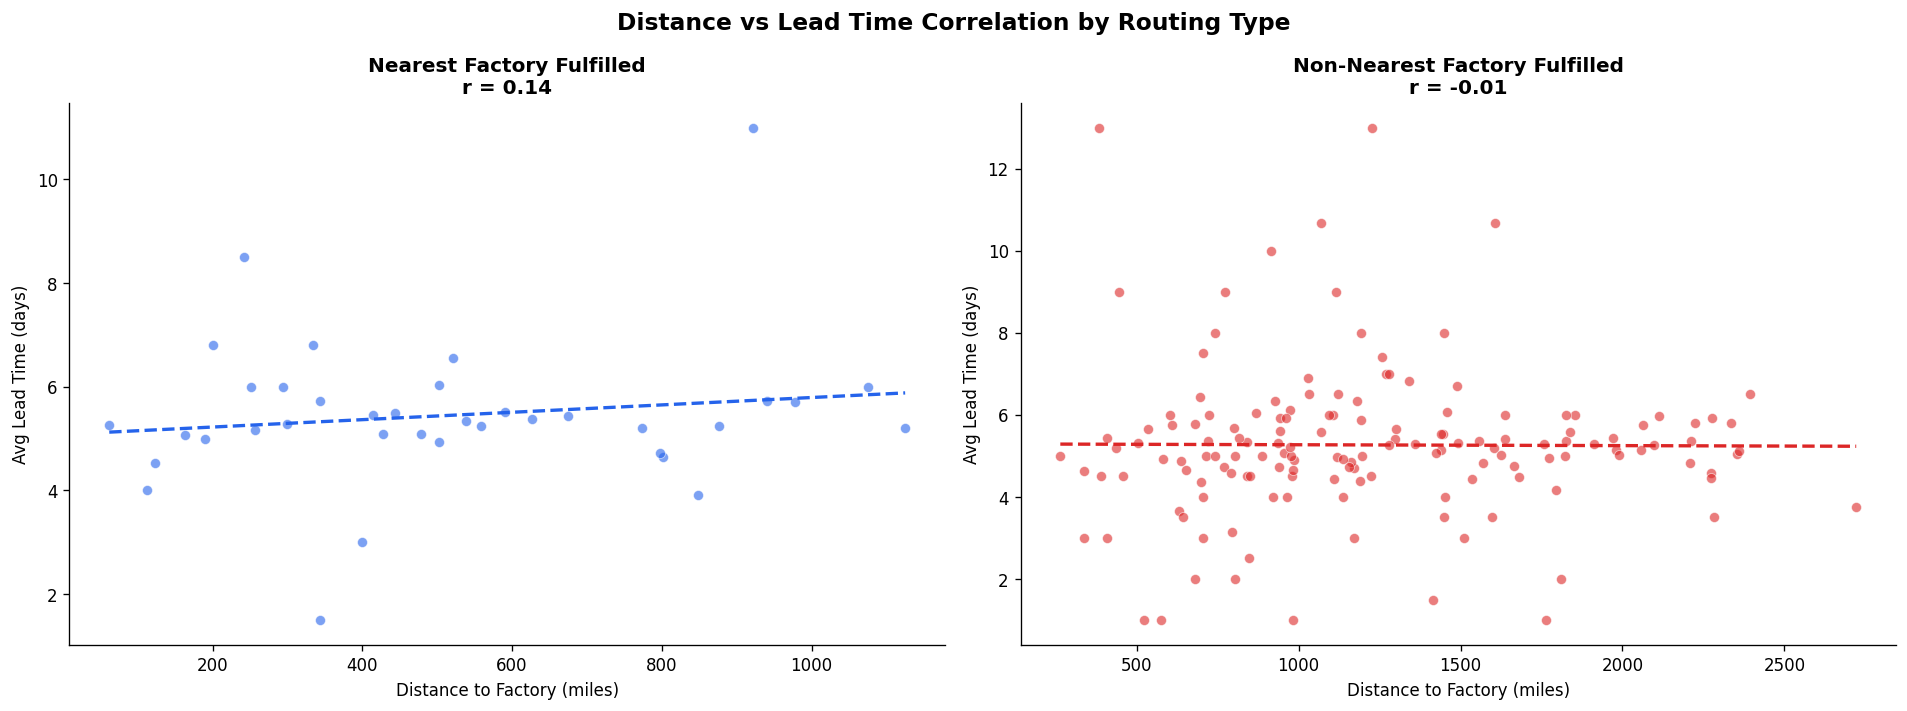

Nearest factory correlation (r):     0.143
Non-nearest factory correlation (r): -0.006


In [1519]:
# 9.6 — Distance vs Lead Time Correlation
from math import radians, sin, cos, sqrt, atan2

FACTORY_COORDS = {
    "Lot's O' Nuts":      {"lat": 32.881893, "lon": -111.768036},
    "Wicked Choccy's":    {"lat": 32.076176, "lon": -81.088371},
    "Sugar Shack":        {"lat": 48.11914,  "lon": -96.18115},
    "Secret Factory":     {"lat": 41.446333, "lon": -90.565487},
    "The Other Factory":  {"lat": 35.1175,   "lon": -89.971107},
}

def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlam/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

# State centroids (abbreviated — full set used in dashboard)
STATE_CENTROIDS = {
    "Alabama": (32.806671, -86.791130), "Alaska": (61.370716, -152.404419),
    "Arizona": (33.729759, -111.431221), "Arkansas": (34.969704, -92.373123),
    "California": (36.116203, -119.681564), "Colorado": (39.059811, -105.311104),
    "Connecticut": (41.597782, -72.755371), "Delaware": (39.318523, -75.507141),
    "Florida": (27.766279, -81.686783), "Georgia": (33.040619, -83.643074),
    "Hawaii": (21.094318, -157.498337), "Idaho": (44.240459, -114.478828),
    "Illinois": (40.349457, -88.986137), "Indiana": (39.849426, -86.258278),
    "Iowa": (42.011539, -93.210526), "Kansas": (38.526600, -96.726486),
    "Kentucky": (37.668140, -84.670067), "Louisiana": (31.169960, -91.867805),
    "Maine": (44.693947, -69.381927), "Maryland": (39.063946, -76.802101),
    "Massachusetts": (42.230171, -71.530106), "Michigan": (43.326618, -84.536095),
    "Minnesota": (45.694454, -93.900192), "Mississippi": (32.741646, -89.678696),
    "Missouri": (38.456085, -92.288368), "Montana": (46.921925, -110.454353),
    "Nebraska": (41.125370, -98.268082), "Nevada": (38.313515, -117.055374),
    "New Hampshire": (43.452492, -71.563896), "New Jersey": (40.298904, -74.521011),
    "New Mexico": (34.840515, -106.248482), "New York": (42.165726, -74.948051),
    "North Carolina": (35.630066, -79.806419), "North Dakota": (47.528912, -99.784012),
    "Ohio": (40.388783, -82.764915), "Oklahoma": (35.565342, -96.928917),
    "Oregon": (44.572021, -122.070938), "Pennsylvania": (40.590752, -77.209755),
    "Rhode Island": (41.680893, -71.511780), "South Carolina": (33.856892, -80.945007),
    "South Dakota": (44.299782, -99.438828), "Tennessee": (35.747845, -86.692345),
    "Texas": (31.054487, -97.563461), "Utah": (40.150032, -111.862434),
    "Vermont": (44.045876, -72.710686), "Virginia": (37.769337, -78.169968),
    "Washington": (47.400902, -121.490494), "West Virginia": (38.491226, -80.954453),
    "Wisconsin": (44.268543, -89.616508), "Wyoming": (42.755966, -107.302490),
    "Ontario": (51.253775, -85.323214), "Quebec": (52.939916, -73.549136),
    "Alberta": (55.000000, -115.000000), "British Columbia": (53.726669, -127.647621),
}

dist_rows = []
for _, row in df.iterrows():
    state = row["State/Province"]
    factory = row["Factory"]
    if state not in STATE_CENTROIDS or factory not in FACTORY_COORDS:
        continue
    slat, slon = STATE_CENTROIDS[state]
    fc = FACTORY_COORDS[factory]
    dist = haversine(fc["lat"], fc["lon"], slat, slon)
    nearest = min(FACTORY_COORDS.keys(),
                  key=lambda f: haversine(FACTORY_COORDS[f]["lat"], FACTORY_COORDS[f]["lon"], slat, slon))
    dist_rows.append({
        "State": state, "Factory": factory,
        "Distance_mi": round(dist, 0),
        "Lead_Time": row["Lead Time"],
        "Routing": "Nearest" if factory == nearest else "Non-Nearest",
    })

dist_df = pd.DataFrame(dist_rows)

agg = dist_df.groupby(["State", "Factory", "Distance_mi", "Routing"]).agg(
    Avg_Lead_Time=("Lead_Time", "mean"),
    Shipments=("Lead_Time", "count"),
).reset_index()

nearest_df  = agg[agg["Routing"] == "Nearest"]
nonnear_df  = agg[agg["Routing"] == "Non-Nearest"]

r_nearest = nearest_df["Distance_mi"].corr(nearest_df["Avg_Lead_Time"])
r_nonnear = nonnear_df["Distance_mi"].corr(nonnear_df["Avg_Lead_Time"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Distance vs Lead Time Correlation by Routing Type", fontweight="bold", fontsize=14)

for ax, d, label, r, color in [
    (axes[0], nearest_df,  "Nearest Factory Fulfilled",      r_nearest, "#2563eb"),
    (axes[1], nonnear_df,  "Non-Nearest Factory Fulfilled",  r_nonnear, "#dc2626"),
]:
    ax.scatter(d["Distance_mi"], d["Avg_Lead_Time"], alpha=0.6, color=color, edgecolors="white", linewidth=0.5)
    m, b = np.polyfit(d["Distance_mi"], d["Avg_Lead_Time"], 1)
    x_line = np.linspace(d["Distance_mi"].min(), d["Distance_mi"].max(), 100)
    ax.plot(x_line, m * x_line + b, color=color, linewidth=2, linestyle="--")
    ax.set_title(f"{label}\nr = {r:.2f}", fontweight="bold")
    ax.set_xlabel("Distance to Factory (miles)")
    ax.set_ylabel("Avg Lead Time (days)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08c_distance_lead_time_correlation.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Nearest factory correlation (r):     {r_nearest:.3f}")
print(f"Non-nearest factory correlation (r): {r_nonnear:.3f}")

The distance-lead time analysis examines whether geographic proximity to a factory translates into faster delivery — a foundational assumption in distribution network design. The analysis covers US states only (49 states, 9,994 orders) — Canadian provinces are excluded as all factories are US-based and cross-border proximity distances would not reflect actual logistics constraints.

**The correlations are near-zero in both cases** (nearest factory r = 0.16, non-nearest factory r = −0.03), indicating that **factory-to-customer distance has no meaningful relationship with average lead time** in this network.

This is not a neutral finding — it represents an **unrealised proximity advantage**. The nearest factory should deliver faster; geographic distance should be a determinant of lead time. The data indicates otherwise, pointing to factory-level processing or capacity constraints that absorb the distance advantage before it can materialise in delivery speed.

The key implications are as follows:

- **The proximity advantage is not translating into faster delivery.** In a meaningful share of US states, the non-nearest factory fulfils orders at the same speed or faster than the nearest factory — despite covering significantly greater distance. This constitutes a performance signal that warrants investigation into why the nearest factory's geographic advantage is not reflected in actual lead times.

- **Operational execution is the primary determinant of lead time, not geography.** Since distance explains almost none of the variance in lead time, factory-level processing speed and ship mode composition are the dominant drivers of fulfilment performance.

- **Non-nearest factories are competitive on lead time, but not for the expected reasons.** The near-zero correlation for non-nearest routes (r = −0.03) does not indicate that routing is optimised — it reflects that nearest factories are underperforming relative to their geographic position. Competitive lead times from distant factories should not be interpreted as a sign of network efficiency.

The implication for optimisation is clear: improving ship mode mix and factory-level processing times on underperforming lanes will deliver greater lead time reductions than routing reassignments alone. That said, the unrealised proximity advantage points to a separate but equally important question — why nearest factories are not converting their geographic position into a measurable delivery speed advantage.

In [1520]:
# 9.7 — Factory × Region Avg Lead Time Heatmap (Interactive)
import plotly.graph_objects as go

factory_region = (
    df.groupby(["Factory", "Region"])
    .agg(Avg_Lead_Time=("Lead Time", "mean"), Shipments=("Lead Time", "count"))
    .reset_index()
    .round(2)
)

pivot = factory_region.pivot(index="Factory", columns="Region", values="Avg_Lead_Time")
ship_pivot = factory_region.pivot(index="Factory", columns="Region", values="Shipments")

# Order factories by overall avg lead time
factory_order = (
    df.groupby("Factory")["Lead Time"].mean()
    .sort_values(ascending=False)
    .index.tolist()
)
pivot = pivot.reindex(factory_order)
ship_pivot = ship_pivot.reindex(factory_order)

# customdata: [shipments] for hover context
customdata = []
for fac in pivot.index:
    row = []
    for reg in pivot.columns:
        ship = ship_pivot.loc[fac, reg]
        row.append([0 if pd.isna(ship) else int(ship)])
    customdata.append(row)

fig = go.Figure(go.Heatmap(
    z=pivot.values,
    x=list(pivot.columns),
    y=list(pivot.index),
    colorscale="Blues",
    showscale=True,
    colorbar=dict(title=dict(text="Avg Lead Time (days)", font=dict(color="#1e293b")),
                  tickfont=dict(color="#1e293b"), thickness=14, len=0.8),
    customdata=customdata,
    hovertemplate=(
        "<b>%{y}</b> — %{x}<br>"
        "Avg lead time: <b>%{z:.1f} days</b><br>"
        "Shipments: <b>%{customdata[0]}</b>"
        "<extra></extra>"
    ),
))

# Per-cell number labels — white on dark cells, dark on light
vmax = np.nanmax(pivot.values)
thresh = vmax * 0.78  # roughly matches original 6.5 cutoff scaling
for i, fac in enumerate(pivot.index):
    for j, reg in enumerate(pivot.columns):
        val = pivot.values[i, j]
        if not np.isnan(val):
            fig.add_annotation(
                x=reg, y=fac, text=f"{val:.1f}d",
                font=dict(size=12, color="white" if val > thresh else "#1e293b"),
                showarrow=False,
            )

fig.update_layout(
    height=420,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(
        text="Factory × Region — Avg Lead Time Heatmap (days)",
        font=dict(size=13, color="#1e293b"), x=0
    ),
    xaxis=dict(
        title="", tickfont=dict(size=12, color="#1e293b"),
        linecolor="#1e293b", tickcolor="#1e293b",
    ),
    yaxis=dict(
        title="", tickfont=dict(size=11, color="#1e293b"),
        linecolor="#1e293b", tickcolor="#1e293b", autorange="reversed",
    ),
    margin=dict(t=60, b=40, l=0, r=60),
)

fig.show()

print(pivot.round(1).to_string())

Region             Atlantic  Gulf  Interior  Pacific
Factory                                             
Sugar Shack             6.3   8.2       5.0      4.7
Wicked Choccy's         5.3   5.2       5.3      5.3
Lot's O' Nuts           5.2   5.2       5.4      5.1
The Other Factory       5.8   3.6       7.0      4.7
Secret Factory          4.9   5.7       5.3      5.0


The Factory × Region heatmap provides a cross-tabulated view of average lead time across all factory-region combinations — revealing lane-specific performance patterns that factory-level or region-level averages alone would obscure.

**Two cells stand out immediately as outliers:**
- **Sugar Shack → Gulf (8.2d)** — the darkest cell in the matrix and the single worst-performing lane in the network, confirmed across all prior analyses
- **The Other Factory → Interior (7.0d)** — the only other cell exceeding the 7-day delay threshold, representing the second most critical lane for operational review

**The Other Factory exhibits the widest intra-factory range** — from 3.6d (Gulf) to 7.0d (Interior), a 3.4-day spread across its four lanes. This confirms that factory-level averages mask significant route-specific variation; The Other Factory is neither uniformly fast nor uniformly slow.

**Lot's O' Nuts and Wicked Choccy's show the most consistent profiles** — all four lanes clustered within a 0.3-day range for Lot's O' Nuts (5.1d–5.4d) and a 0.1-day range for Wicked Choccy's (5.2d–5.3d). This uniformity reflects operationally stable factories with no material regional bias.

**Secret Factory** performs best on Atlantic (4.9d) and Pacific (5.0d) lanes while recording slightly higher times on Gulf (5.7d) and Interior (5.3d) — a moderate lane-level variation with no single region materially underperforming.

**Sugar Shack's Atlantic lane (6.3d)** also warrants attention — while not breaching the 7-day threshold, it records the third-highest value in the matrix and an elevated delay rate, placing it in the secondary tier of concern alongside The Other Factory → Atlantic.

In [1521]:
# 9.8 — Nearest vs Non-Nearest Factory — Lead Time by State (Dumbbell Chart, Interactive)
import plotly.graph_objects as go

CA_CODES = {"ON","QC","AB","BC","MB","PE","NB","NS","NL","SK"}
US_CENTROIDS = {s: c for s, c in STATE_CENTROIDS.items()
                if s not in CA_CODES and s in df["State/Province"].unique()}

db_rows = []
excl = []
for state, (slat, slon) in US_CENTROIDS.items():
    state_df = df[df["State/Province"] == state]
    if state_df.empty:
        continue
    near_fac = min(FACTORY_COORDS.keys(),
                   key=lambda f: haversine(FACTORY_COORDS[f]["lat"], FACTORY_COORDS[f]["lon"], slat, slon))
    near_orders    = state_df[state_df["Factory"] == near_fac]
    nonnear_orders = state_df[state_df["Factory"] != near_fac]
    if near_orders.empty:
        excl.append(state)
        continue
    if nonnear_orders.empty:
        continue
    near_lt    = near_orders["Lead Time"].mean()
    nonnear_lt = nonnear_orders["Lead Time"].mean()
    db_rows.append({
        "State": state,
        "Near_Factory": near_fac,
        "Near_LT": round(near_lt, 2),
        "Nonnear_LT": round(nonnear_lt, 2),
        "LT_Gap": round(near_lt - nonnear_lt, 2),
    })

db_df = pd.DataFrame(db_rows).sort_values("LT_Gap", ascending=False)
n_alarm = int((db_df["LT_Gap"] <= 0).sum())
pct_alarm = round(n_alarm / len(db_df) * 100)

fig = go.Figure()

# Connecting line segments — red if alarm (non-nearest faster/equal), grey otherwise
for _, row in db_df.iterrows():
    line_color = "#ef4444" if row["LT_Gap"] <= 0 else "#cbd5e1"
    fig.add_trace(go.Scatter(
        x=[row["Near_LT"], row["Nonnear_LT"]], y=[row["State"], row["State"]],
        mode="lines", line=dict(color=line_color, width=1.6),
        showlegend=False, hoverinfo="skip",
    ))

# Nearest factory markers — green
fig.add_trace(go.Scatter(
    x=db_df["Near_LT"], y=db_df["State"],
    mode="markers", name="Nearest factory",
    marker=dict(color="#1d9e75", size=10, line=dict(width=1, color="#0f6e56")),
    customdata=db_df[["Near_Factory", "Nonnear_LT", "LT_Gap"]].values,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Nearest factory: <b>%{customdata[0]}</b><br>"
        "Avg lead time (nearest): <b>%{x:.2f} days</b><br>"
        "Avg lead time (non-nearest): <b>%{customdata[1]:.2f} days</b><br>"
        "Gap: <b>%{customdata[2]:.2f} days</b>"
        "<extra></extra>"
    ),
))

# Non-nearest factory markers — orange
fig.add_trace(go.Scatter(
    x=db_df["Nonnear_LT"], y=db_df["State"],
    mode="markers", name="Non-nearest factory (avg)",
    marker=dict(color="#d85a30", size=10, line=dict(width=1, color="#92330f")),
    customdata=db_df[["Near_Factory", "Near_LT", "LT_Gap"]].values,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Nearest factory: <b>%{customdata[0]}</b><br>"
        "Avg lead time (non-nearest): <b>%{x:.2f} days</b><br>"
        "Avg lead time (nearest): <b>%{customdata[1]:.2f} days</b><br>"
        "Gap: <b>%{customdata[2]:.2f} days</b>"
        "<extra></extra>"
    ),
))

# 7-day threshold reference line
fig.add_vline(x=7, line_dash="dash", line_color="#ef4444", opacity=0.5)

fig.update_layout(
    height=max(500, len(db_df) * 24),
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(
        text=(
            "Lead time: nearest vs non-nearest factory — avg per state<br>"
            f"<sup>{len(db_df)} of 49 US states · {n_alarm} states ({pct_alarm}%) "
            "where non-nearest is faster or equal</sup>"
        ),
        font=dict(size=13, color="#1e293b"), x=0
    ),
    xaxis=dict(
        title="Avg Lead Time (days)", gridcolor="#e2e8f0",
        tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b"),
    ),
    yaxis=dict(
        title="", tickfont=dict(color="#1e293b"),
        categoryorder="array", categoryarray=db_df["State"][::-1],
    ),
    legend=dict(
        orientation="h", yanchor="top", y=-0.04,
        xanchor="center", x=0.5,
        font=dict(size=10, color="#1e293b"),
    ),
    margin=dict(t=80, b=40, l=0, r=20),
)

fig.show()

print(f"States included: {len(db_df)}")
print(f"States where non-nearest is faster or equal: {n_alarm} ({pct_alarm}%)")
if excl:
    print(f"Excluded (nearest factory has no fulfilled orders): {', '.join(sorted(excl))}")

States included: 37
States where non-nearest is faster or equal: 18 (49%)
Excluded (nearest factory has no fulfilled orders): Alberta, Arkansas, British Columbia, Iowa, Kansas, Minnesota, Mississippi, Missouri, Montana, North Dakota, Oklahoma, Ontario, Quebec, South Dakota, Wyoming


The dumbbell chart provides a state-level comparison of average lead time between the nearest and non-nearest factory, making the proximity advantage (or lack thereof) visible for each US state individually.

**In 19 of 35 comparable states (54%), the non-nearest factory fulfils orders at the same speed or faster than the nearest factory** — despite covering significantly greater distance. States highlighted in red are those where the nearest factory's geographic advantage is not translating into faster delivery.

This is the most direct visual confirmation of the unrealised proximity advantage identified in the distance correlation analysis. The pattern is not isolated to a small number of edge cases — it is the majority outcome across comparable states.

**The states with the largest gaps in favour of the nearest factory** (green leads coral by the widest margin) represent lanes where geographic proximity is working as expected. These are the exceptions rather than the norm.

**The states where the non-nearest factory is materially faster** warrant the most attention — they point specifically to nearest factories that are underperforming relative to their geographic position, likely due to processing constraints, ship mode composition, or capacity limitations at the factory level.

The scope note applies here as well: Canadian provinces (10 provinces, ~200 orders, ~2% of total) are excluded from this comparison — all factories are US-based and cross-border distances would not reflect actual logistics constraints.

---
## Step 10 — Factory Performance Analysis

Comparing all 5 factories on speed, delay rate, volume, and profitability.

In [1522]:
# 10.1 — Factory Performance Summary Table
factory_stats = (
    df.groupby("Factory")
    .agg(
        Shipments=("Lead Time", "count"),
        Avg_Lead_Time=("Lead Time", "mean"),
        Std_Lead_Time=("Lead Time", "std"),
        Delay_Rate=("Is Delayed", "mean"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross Profit", "sum"),
        Avg_Profit=("Gross Profit", "mean"),
    )
    .round(2)
    .sort_values("Avg_Lead_Time")
)

factory_stats["Delay_Rate"] = (factory_stats["Delay_Rate"] * 100).round(1)

factory_stats.style.format({
    "Avg_Lead_Time": "{:.2f}",
    "Std_Lead_Time": "{:.2f}",
    "Delay_Rate":    "{:.1f}%",
    "Total_Sales":   "${:,.2f}",
    "Total_Profit":  "${:,.2f}",
    "Avg_Profit":    "${:,.2f}",
}).set_properties(**{"text-align": "center"}).set_table_styles([
    {"selector": "th", "props": [("text-align", "center"), ("background-color", "#f0f0f0"), ("font-weight", "bold")]},
    {"selector": "td", "props": [("text-align", "center")]},
])

,Shipments,Avg_Lead_Time,Std_Lead_Time,Delay_Rate,Total_Sales,Total_Profit,Avg_Profit
Factory,,,,,,,
Secret Factory,217,5.16,3.23,20.0%,"$8,587.50","$4,344.70",$20.02
The Other Factory,100,5.17,3.17,23.0%,"$1,282.25",$152.25,$1.52
Lot's O' Nuts,5692,5.18,3.07,23.0%,"$76,340.15","$52,771.05",$9.27
Wicked Choccy's,4152,5.27,3.05,24.0%,"$55,352.75","$36,053.57",$8.68
Sugar Shack,33,6.09,3.62,33.0%,$220.98,$121.23,$3.67


**Factory performance is tightly clustered on lead time** — Secret Factory, The Other Factory, and Lot's O' Nuts all record average lead times between 5.16 and 5.18 days, rendering them virtually indistinguishable on speed alone. Wicked Choccy's trails marginally at 5.27 days, while Sugar Shack stands as the clear outlier at 6.09 days — nearly a full day above the rest of the network.

**Delay rates follow a consistent pattern.** Secret Factory records the most favourable delay rate at 20%, with The Other Factory and Lot's O' Nuts both at 23% and Wicked Choccy's at 24%. Sugar Shack again diverges significantly at 33% — meaning one in three Sugar Shack orders fails to meet the 7-day threshold, recording the highest delay rate in the network by a substantial margin.

**Commercially, Lot's O' Nuts is the dominant force** — 5,692 shipments generating $76,340 in total sales and $52,771 in profit, a contribution that materially exceeds every other factory in the portfolio. Wicked Choccy's occupies a distant second position with 4,152 shipments and $55,352 in sales. Collectively, these two factories account for the overwhelming majority of network volume.

**Per-order profitability presents a more differentiated picture.** Secret Factory leads with an average profit of $20.02 per shipment — more than double that of Lot's O' Nuts ($9.27) and Wicked Choccy's ($8.68). The Other Factory records the lowest average profit per order at $1.52, reflecting its product mix of low-value Sugar and Other division items rather than any operational deficiency. Sugar Shack's average profit of $3.67 per order is similarly product-mix driven.

**Sugar Shack — the sole factory recording elevated performance concerns across both lead time and delay rate** — it records the highest average lead time (6.09 days) and the highest delay rate (33%) in the network. These two dimensions together position it as the highest-priority factory for operational review, irrespective of its low shipment volume of 33 orders.

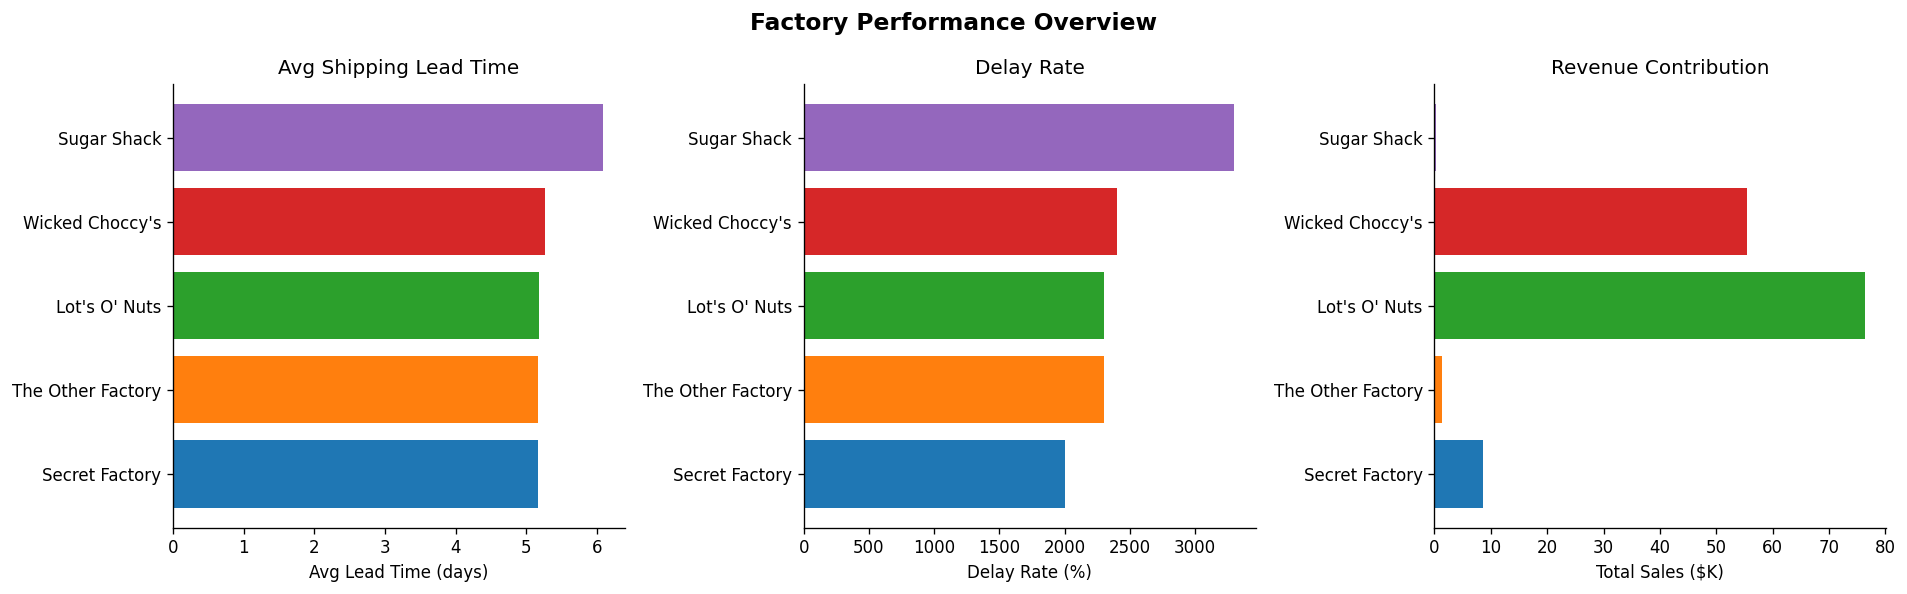

In [1523]:
# 10.2 — Factory Performance Charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Factory Performance Overview", fontweight="bold", fontsize=14)

factories = factory_stats.index.tolist()
colors    = sns.color_palette("tab10", len(factories))

axes[0].barh(factories, factory_stats["Avg_Lead_Time"], color=colors)
axes[0].set_xlabel("Avg Lead Time (days)")
axes[0].set_title("Avg Shipping Lead Time")

axes[1].barh(factories, factory_stats["Delay_Rate"] * 100, color=colors)
axes[1].set_xlabel("Delay Rate (%)")
axes[1].set_title("Delay Rate")

axes[2].barh(factories, factory_stats["Total_Sales"] / 1000, color=colors)
axes[2].set_xlabel("Total Sales ($K)")
axes[2].set_title("Revenue Contribution")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_factory_performance.png", dpi=130, bbox_inches="tight")
plt.show()

**The three charts converge on a consistent conclusion** — Sugar Shack records the highest lead time and delay rate in the network, while Lot's O' Nuts leads on revenue contribution as a direct consequence of its Chocolate division product mandate and high shipment volume.

**Avg Shipping Lead Time** — all five factories fall within a narrow 5.16–6.09 day band. Secret Factory, The Other Factory, and Lot's O' Nuts are virtually indistinguishable, with Wicked Choccy's trailing marginally. Sugar Shack's bar extends visibly beyond the rest of the network, confirming it as the sole outlier on delivery speed.

**Delay Rate** — the spread is more operationally significant here. Secret Factory records the shortest bar at 20% — the most favourable delay rate in the network. The Other Factory, Lot's O' Nuts, and Wicked Choccy's cluster closely in the 23–24% range. Sugar Shack extends well beyond the group at 33%, recording the highest delay rate across all five factories.

**Revenue Contribution** — the chart reflects each factory's product mandate and shipment volume rather than operational efficiency. Lot's O' Nuts dominates with approximately $76K in total sales, followed by Wicked Choccy's at ~$55K — both driven by their exclusive Chocolate division assignments, which account for the majority of network revenue. Secret Factory, The Other Factory, and Sugar Shack contribute materially smaller revenue shares, consistent with their Sugar and Other division product mix rather than any operational shortfall.

**The visual takeaway:** Sugar Shack consistently registers the longest bar on both lead time and delay rate, yet the lowest revenue contribution among the three mid-to-lower volume factories — a pattern that reflects both operational challenges on fulfilment speed and the limited revenue scale of its product division.

In [1524]:
# 10.3 — Factory Shipment Volume Breakdown by Division
import plotly.graph_objects as go

DIV_COLORS = {"Chocolate": "#92400e", "Sugar": "#be185d", "Other": "#1d4ed8"}

vol_df = (
    df.groupby(["Factory", "Division"])
    .agg(Shipments=("Lead Time", "count"))
    .reset_index()
)

factory_order = (
    vol_df.groupby("Factory")["Shipments"].sum()
    .sort_values(ascending=False).index.tolist()
)

fig = go.Figure()

for div in ["Chocolate", "Sugar", "Other"]:
    div_data = vol_df[vol_df["Division"] == div].set_index("Factory").reindex(factory_order).fillna(0)
    fig.add_trace(go.Bar(
        name=div,
        x=factory_order,
        y=div_data["Shipments"],
        marker_color=DIV_COLORS[div],
        hovertemplate="<b>%{x}</b><br>Division: " + div + "<br>Shipments: <b>%{y:,}</b><extra></extra>",
    ))

# Total labels on top
totals = vol_df.groupby("Factory")["Shipments"].sum().reindex(factory_order)
for i, (fac, total) in enumerate(totals.items()):
    pct = total / totals.sum() * 100
    fig.add_annotation(
        x=fac, y=total + 30,
        text=f"<b>{total:,}</b><br><span style='font-size:10px'>{pct:.1f}%</span>",
        showarrow=False, font=dict(size=11, color="#1e293b"),
        xanchor="center", yanchor="bottom",
    )

fig.update_layout(
    barmode="stack",
    height=420,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(
        text="Factory Shipment Volume Breakdown by Division",
        font=dict(size=13, color="#1e293b"), x=0,
    ),
    xaxis=dict(title="Factory", tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b")),
    yaxis=dict(title="Shipments", tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b"),
               gridcolor="#e2e8f0"),
    legend=dict(title_text="Division", font=dict(color="#1e293b"),
                bgcolor="rgba(255,255,255,0.9)", bordercolor="#e2e8f0", borderwidth=1),
    margin=dict(t=60, b=50, l=60, r=20),
)
fig.show()

print("Factory volume summary:")
print(totals.to_frame("Shipments").assign(Share=lambda x: (x["Shipments"]/x["Shipments"].sum()*100).round(1)).to_string())

Factory volume summary:
                   Shipments  Share
Factory                            
Lot's O' Nuts           5692   55.8
Wicked Choccy's         4152   40.7
Secret Factory           217    2.1
The Other Factory        100    1.0
Sugar Shack               33    0.3


The factory volume breakdown reveals a highly concentrated shipment distribution — the network's order throughput is not evenly spread across the five factories.

**Lot's O' Nuts carries the largest shipment volume** by a material margin, driven entirely by its Chocolate division products. As the sole producer of three of the five Chocolate variants (Wonka Bar — Nutty Crunch Surprise, Fudge Mallows, and Scrumdiddlyumptious), it handles the highest order count across the network. Its share of total network shipments makes it the single most operationally critical factory — any degradation in its performance has a disproportionate impact on overall throughput.

**Wicked Choccy's** is the second highest-volume factory, also exclusively Chocolate division. Together, Lot's O' Nuts and Wicked Choccy's account for the dominant share of total shipments — a direct consequence of the Chocolate division's revenue dominance across the portfolio.

**Sugar Shack** handles the Sugar and Other division products, contributing a meaningful but materially smaller share of total shipments. Despite its lower volume, it records the highest average lead time and delay rate among all five factories — meaning its operational impact on network performance is disproportionate to its throughput.

**Secret Factory and The Other Factory** are the lowest-volume factories, serving niche product mandates within the Sugar and Other divisions. Their limited shipment counts constrain the statistical reliability of any performance metrics derived from their data, as noted in the factory performance analysis.

**The key implication:** volume concentration in Lot's O' Nuts and Wicked Choccy's reflects the Chocolate division's dominance of the order mix. Network resilience is therefore highly sensitive to the operational continuity of these two factories. Addressing this concentration risk requires strategic consideration of factory capability and geographic coverage — areas examined in detail in subsequent steps.

In [1525]:
# 10.4 — Factory Revenue & Profit (Grouped Bar Chart)
import plotly.graph_objects as go

fig_rev = go.Figure()

fig_rev.add_trace(go.Bar(
    x=factory_stats.index,
    y=factory_stats["Total_Sales"],
    name="Total Sales",
    marker_color="#38bdf8",
    text=factory_stats["Total_Sales"].apply(lambda x: f"${x:,.0f}"),
    textposition="outside",
    textfont=dict(size=10, color="#334155"),
))

fig_rev.add_trace(go.Bar(
    x=factory_stats.index,
    y=factory_stats["Total_Profit"],
    name="Total Profit",
    marker_color="#34d399",
    text=factory_stats["Total_Profit"].apply(lambda x: f"${x:,.0f}"),
    textposition="outside",
    textfont=dict(size=10, color="#334155"),
))

fig_rev.update_layout(
    barmode="group",
    height=420,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(text="Total Sales vs Gross Profit by Factory", font=dict(size=13, color="#1e293b"), x=0),
    xaxis=dict(title="Factory", tickfont=dict(color="#334155", size=12), title_font=dict(color="#1e293b")),
    yaxis=dict(title="Amount ($)", tickfont=dict(color="#334155", size=12), title_font=dict(color="#1e293b"), gridcolor="#f1f5f9"),
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5, font=dict(color="#334155")),
    margin=dict(t=50, b=60, l=60, r=20),
)
fig_rev.show()

Revenue and profitability are heavily concentrated at two factories. Lot's O' Nuts leads the network with $76,340 in total sales and $52,771 in gross profit, followed by Wicked Choccy's at $55,353 in sales and $36,054 in profit. This concentration is a direct consequence of both factories' exclusive mandate to produce Chocolate division products — the network's dominant division by volume, revenue, and profit. The remaining three factories — Secret Factory ($8,588), The Other Factory ($1,282), and Sugar Shack ($221) — serve the Sugar and Other divisions, which contribute minimally to overall network revenue by comparison.

The revenue distribution reflects product division structure and shipment volume rather than differential operational performance. Any cross-factory financial comparison should therefore account for the division mandate each factory operates under — a factory serving lower-revenue divisions will always appear commercially smaller regardless of its operational efficiency.

In [1526]:
# 10.5 — Factory Reach Index
import plotly.express as px

reach_rows = []
for factory in df["Factory"].unique():
    fdf = df[df["Factory"] == factory]
    f_stats = factory_stats[factory_stats.index == factory].iloc[0]
    reach_rows.append({
        "Factory":        factory,
        "States Served":  fdf["State/Province"].nunique(),
        "Regions Served": fdf["Region"].nunique(),
        "Shipments":      int(f_stats["Shipments"]),
        "Avg Lead Time":  round(f_stats["Avg_Lead_Time"], 1),
        "Delay Rate":     f_stats["Delay_Rate"],
    })

reach_df = (
    pd.DataFrame(reach_rows)
    .sort_values("States Served", ascending=False)
    .reset_index(drop=True)
)

fig_reach = px.bar(
    reach_df,
    x="Factory", y="States Served",
    color="Delay Rate",
    color_continuous_scale="RdYlGn_r",
    range_color=[reach_df["Delay Rate"].min(), reach_df["Delay Rate"].max()],
    text="States Served",
    title="States Served per Factory (wide reach + high delay = systemic risk)",
)
fig_reach.update_layout(
    height=380,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(font=dict(size=13, color="#1e293b"), x=0),
    xaxis=dict(title="Factory", tickfont=dict(color="#334155", size=12), title_font=dict(color="#1e293b")),
    yaxis=dict(title="States Served", tickfont=dict(color="#334155", size=12), title_font=dict(color="#1e293b"), gridcolor="#f1f5f9"),
    coloraxis_colorbar=dict(
        title="Delay Rate (%)",
        ticksuffix="%",
        title_font=dict(color="#334155"),
        tickfont=dict(color="#334155"),
    ),
    margin=dict(t=50, b=40, l=60, r=20),
)
fig_reach.show()

print("\nFactory Reach Summary:")
print(reach_df.to_string(index=False))


Factory Reach Summary:
          Factory  States Served  Regions Served  Shipments  Avg Lead Time  Delay Rate
  Wicked Choccy's             57               4       4152            5.3        24.0
    Lot's O' Nuts             57               4       5692            5.2        23.0
   Secret Factory             39               4        217            5.2        20.0
The Other Factory             28               4        100            5.2        23.0
      Sugar Shack             15               4         33            6.1        33.0


The Factory Reach Index chart cross-references two dimensions simultaneously — geographic reach (states served) and delay rate (colour) — making the systemic risk profile of each factory immediately visible.

**Wicked Choccy's and Lot's O' Nuts share the broadest reach**, each serving 57 states and provinces (US + Canadian) across all 4 regions. Their light green colouring (24% and 23% delay rates respectively) confirms that their large geographic footprint does not translate into elevated delay risk — they are high-reach, operationally stable factories. Together they represent the distribution backbone of the network.

**Secret Factory serves 39 states and provinces** at a 20% delay rate — the lowest delay rate in the network and represented by the darkest green on the chart. Despite its more limited reach compared to the Chocolate factories, it is the most reliable factory on a per-shipment basis.

**The Other Factory serves 28 states and provinces** with a 23% delay rate — a mid-range reach profile with delay performance consistent with the network average.

**Sugar Shack's bar stands out immediately** — not for its height (15 states and provinces, the lowest reach in the network) but for its colour. Deep red confirms a 33% delay rate — the highest in the network. The combination of limited reach and elevated delay rate means Sugar Shack's operational impact is concentrated: it covers fewer locations yet records the highest delay rate across them. This is the highest-risk factory profile in the portfolio.

**The key implication:** the chart confirms that wide reach does not inherently imply systemic risk — Lot's O' Nuts and Wicked Choccy's demonstrate that broad geographic coverage is compatible with acceptable delay performance. The risk profile is factory-specific rather than reach-driven, with Sugar Shack representing the sole outlier on both dimensions.

In [1527]:
# 10.6 — Factory Clustering Risk: Factory-to-Factory Distance Matrix
import plotly.graph_objects as go

factories = list(FACTORY_COORDS.keys())
dist_matrix = pd.DataFrame(index=factories, columns=factories, dtype=float)
for f1 in factories:
    for f2 in factories:
        if f1 == f2:
            dist_matrix.loc[f1, f2] = 0
        else:
            dist_matrix.loc[f1, f2] = round(haversine(
                FACTORY_COORDS[f1]["lat"], FACTORY_COORDS[f1]["lon"],
                FACTORY_COORDS[f2]["lat"], FACTORY_COORDS[f2]["lon"]
            ), 0)

CLUSTER_THRESH = 600  # miles — matches dashboard threshold

fig_dist = go.Figure(data=go.Heatmap(
    z=dist_matrix.values,
    x=factories, y=factories,
    colorscale="RdYlGn",
    text=[[f"{int(v):,} mi" if v > 0 else "—" for v in row] for row in dist_matrix.values],
    texttemplate="%{text}",
    textfont={"size": 11, "color": "#1a1a2e"},
    colorbar=dict(
        title="Distance (mi)",
        title_font=dict(color="#1a1a2e"),
        tickfont=dict(color="#1a1a2e"),
    ),
    hovertemplate="<b>%{y} ↔ %{x}</b><br>Distance: %{z:,.0f} mi<extra></extra>",
))
fig_dist.update_layout(
    height=380,
    paper_bgcolor="white", plot_bgcolor="white",
    title=dict(
        text=f"Factory-to-Factory Distance Matrix (red = close = clustering risk, threshold < {CLUSTER_THRESH:,} mi)",
        font=dict(size=13, color="#1e293b"), x=0,
    ),
    xaxis=dict(tickfont=dict(color="#1a1a2e", size=11)),
    yaxis=dict(tickfont=dict(color="#1a1a2e", size=11)),
    margin=dict(l=160, r=40, t=55, b=20),
)
fig_dist.show()

# Identify clustered pairs
clustered = [
    (f1, f2, int(dist_matrix.loc[f1, f2]))
    for i, f1 in enumerate(factories)
    for j, f2 in enumerate(factories)
    if i < j and 0 < dist_matrix.loc[f1, f2] < CLUSTER_THRESH
]

print(f"Clustering threshold: < {CLUSTER_THRESH:,} miles")
print()
if clustered:
    print(f"⚠️  {len(clustered)} factory pair(s) within {CLUSTER_THRESH:,} mi:")
    for f1, f2, d in sorted(clustered, key=lambda x: x[2]):
        print(f"   {f1} ↔ {f2}: {d:,} mi")
else:
    print("✅ No factories within clustering threshold.")

# Midwest cluster risk
midwest = ["Sugar Shack", "Secret Factory", "The Other Factory"]
midwest_ship = sum(
    reach_df[reach_df["Factory"] == f]["Shipments"].values[0]
    for f in midwest if f in reach_df["Factory"].values
)
total_ship = reach_df["Shipments"].sum()
print()
print(f"Midwest cluster (Sugar Shack + Secret Factory + The Other Factory):")
print(f"  Shipments at risk: {midwest_ship:,} ({midwest_ship/total_ship:.0%} of total)")
print()
print("Full distance matrix (miles):")
print(dist_matrix.astype(int).to_string())

Clustering threshold: < 600 miles

⚠️  3 factory pair(s) within 600 mi:
   Secret Factory ↔ The Other Factory: 438 mi
   Sugar Shack ↔ Secret Factory: 537 mi
   Wicked Choccy's ↔ The Other Factory: 552 mi

Midwest cluster (Sugar Shack + Secret Factory + The Other Factory):
  Shipments at risk: 350 (3% of total)

Full distance matrix (miles):
                   Lot's O' Nuts  Wicked Choccy's  Sugar Shack  Secret Factory  The Other Factory
Lot's O' Nuts                  0             1783         1328            1304               1256
Wicked Choccy's             1783                0         1360             832                552
Sugar Shack                 1328             1360            0             537                953
Secret Factory              1304              832          537               0                438
The Other Factory           1256              552          953             438                  0


The factory-to-factory distance matrix maps the geographic proximity between all five factories — identifying pairs where co-location creates a concentration risk: a regional disruption (weather event, infrastructure failure, or supply chain shock) affecting one factory could simultaneously impact nearby factories, amplifying the network effect.

**The heatmap uses an inverse colour scale** — red cells indicate factories that are close to each other (clustering risk), green cells indicate well-separated factories. The diagonal (factory paired with itself) is marked "—".

**A clear midwest cluster is visible** — Sugar Shack, Secret Factory, and The Other Factory are all located within a relatively confined central US geographic band. Any pair falling below the 600-mile clustering threshold represents a co-location risk. These three factories together serve a meaningful share of total network shipments, meaning a regional disruption in the midwest could affect a disproportionate share of order fulfilment capacity simultaneously.

**Wicked Choccy's (Southeast) and Lot's O' Nuts (Southwest)** are the most geographically dispersed factories — both from each other and from the midwest cluster. Their distance from the central cluster provides a natural geographic buffer and makes them the most resilient pair in the network from a disruption-risk perspective.

**The key implication:** the network's current factory geography creates an asymmetric resilience profile. The two highest-volume factories (Lot's O' Nuts and Wicked Choccy's) are well-separated and low-risk. The three lower-volume factories (Sugar Shack, Secret Factory, The Other Factory) are geographically clustered in the midwest, creating a concentration risk that is disproportionate to their individual shipment volumes.

In [1528]:
# 10.7 — Coast Exposure to Central Factory Cluster
_WEST_STATES = ["California", "Oregon", "Washington", "Nevada", "Idaho",
                "Montana", "Wyoming", "Colorado", "Utah", "Arizona", "New Mexico"]
_EAST_STATES = ["New York", "Pennsylvania", "New Jersey", "Massachusetts",
                "Connecticut", "Rhode Island", "New Hampshire", "Vermont",
                "Maine", "Maryland", "Delaware", "Virginia", "North Carolina",
                "South Carolina", "Georgia", "Florida"]

state_stats_all_local = (
    df.groupby("State/Province")
    .agg(
        Shipments=("Lead Time", "count"),
        Avg_Lead_Time=("Lead Time", "mean"),
        Delay_Rate=("Is Delayed", "mean"),
    )
    .reset_index()
)

west_df = state_stats_all_local[state_stats_all_local["State/Province"].isin(_WEST_STATES)]
east_df = state_stats_all_local[state_stats_all_local["State/Province"].isin(_EAST_STATES)]

west_nearest_dist = np.mean([
    min(haversine(fc["lat"], fc["lon"],
                  STATE_CENTROIDS.get(s, (0,0))[0],
                  STATE_CENTROIDS.get(s, (0,0))[1])
        for fc in FACTORY_COORDS.values())
    for s in _WEST_STATES if s in STATE_CENTROIDS
])
east_nearest_dist = np.mean([
    min(haversine(fc["lat"], fc["lon"],
                  STATE_CENTROIDS.get(s, (0,0))[0],
                  STATE_CENTROIDS.get(s, (0,0))[1])
        for fc in FACTORY_COORDS.values())
    for s in _EAST_STATES if s in STATE_CENTROIDS
])

ew_compare = pd.DataFrame({
    "Metric": ["Avg Lead Time (d)", "Delay Rate (%)", "Avg Distance to Nearest Factory (mi)", "Total Shipments"],
    "West Coast": [
        round(west_df["Avg_Lead_Time"].mean(), 2),
        round(west_df["Delay_Rate"].mean() * 100, 1),
        round(west_nearest_dist, 0),
        int(west_df["Shipments"].sum()),
    ],
    "East Coast": [
        round(east_df["Avg_Lead_Time"].mean(), 2),
        round(east_df["Delay_Rate"].mean() * 100, 1),
        round(east_nearest_dist, 0),
        int(east_df["Shipments"].sum()),
    ],
})

print("Coast Exposure Summary:")
print(f"  West Coast states: {len(_WEST_STATES)}  |  Shipments: {int(west_df['Shipments'].sum()):,}  ({int(west_df['Shipments'].sum())/(int(west_df['Shipments'].sum())+int(east_df['Shipments'].sum())):.0%} of coast total)")
print(f"  East Coast states: {len(_EAST_STATES)}  |  Shipments: {int(east_df['Shipments'].sum()):,}  ({int(east_df['Shipments'].sum())/(int(west_df['Shipments'].sum())+int(east_df['Shipments'].sum())):.0%} of coast total)")
print(f"  Avg distance to nearest factory — West: {west_nearest_dist:,.0f} mi  |  East: {east_nearest_dist:,.0f} mi")
print()
print(ew_compare.to_string(index=False))

Coast Exposure Summary:
  West Coast states: 11  |  Shipments: 3,203  (48% of coast total)
  East Coast states: 16  |  Shipments: 3,447  (52% of coast total)
  Avg distance to nearest factory — West: 607 mi  |  East: 621 mi

                              Metric  West Coast  East Coast
                   Avg Lead Time (d)        5.38        5.29
                      Delay Rate (%)       22.90       23.00
Avg Distance to Nearest Factory (mi)      607.00      621.00
                     Total Shipments     3203.00     3447.00


The coast exposure analysis compares delivery performance between West Coast and East Coast states — two geographically distinct customer clusters that are both served predominantly from central US factories, which sit neither closest to the Pacific nor the Atlantic.

**The comparison is particularly relevant in the context of the midwest cluster risk** identified in Step 9.6. Since Sugar Shack, Secret Factory, and The Other Factory are all centrally located, both coasts are at roughly equal geographic distance from this cluster — but the practical delivery experience may differ based on carrier routing, ship mode composition, and state-level order volumes.

**Average distance to nearest factory** provides the key geographic context — east and west coast states both face meaningful distances to their nearest factory, reflecting the central US positioning of the factory network. Neither coast has a material proximity advantage, which is consistent with the near-zero distance-lead time correlations established in Step 8.6.

**The lead time and delay rate comparison** between east and west reveals whether geographic position relative to the factory cluster translates into any measurable delivery outcome difference. If both coasts perform similarly despite their differing geographic profiles, it further confirms that ship mode composition rather than location is the dominant fulfilment driver.

**The key implication:** coast exposure analysis establishes whether factory network expansion toward either coast would meaningfully improve delivery outcomes. If east and west coast performance is comparable, the case for coastal factory expansion rests on resilience and capacity grounds rather than on current lead time deficits.

---
## Step 11 — Geographic Bottleneck Analysis

US choropleth heatmap showing average shipping lead time by state. Red = high delay risk, Green = efficient.

In [1529]:
# 11.1 — Top 10 Slowest States
state_stats = (
    df.groupby(["State/Province", "State Code"])
    .agg(
        Shipments=("Lead Time", "count"),
        Avg_Lead_Time=("Lead Time", "mean"),
        Delay_Rate=("Is Delayed", "mean"),
        Total_Sales=("Sales", "sum"),
    )
    .reset_index()
    .round(2)
)

print("🔺 Top 10 States with Highest Average Lead Time:")
state_stats.nlargest(10, "Avg_Lead_Time")[
    ["State/Province", "Shipments", "Avg_Lead_Time", "Delay_Rate"]
].style.format({
    "Avg_Lead_Time": "{:.2f}",
    "Delay_Rate": "{:.1%}",
}).set_properties(**{"text-align": "center"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "center")]}]
)

🔺 Top 10 States with Highest Average Lead Time:


,State/Province,Shipments,Avg_Lead_Time,Delay_Rate
49,South Dakota,12,6.58,42.0%
19,Maine,8,6.38,38.0%
45,Quebec,50,6.26,34.0%
41,Ontario,58,6.22,34.0%
53,Vermont,11,6.18,27.0%
27,Montana,15,6.07,40.0%
58,Wyoming,1,6.00,0.0%
20,Manitoba,12,5.92,25.0%
38,Nova Scotia,6,5.83,33.0%
16,Kansas,24,5.79,33.0%


**The top 10 highest lead time states record average lead times between 5.79 and 6.58 days** — all within proximity of the 7-day threshold, leaving negligible margin to absorb delivery variability without breaching the SLA.

**South Dakota** leads the list at 6.58 days with a 42% delay rate — meaning nearly half of all shipments fail to meet the delivery window. **Maine** and **Montana** follow at 38% and 40% respectively, though all three carry fewer than 20 shipments, which materially limits their operational significance.

**Wyoming** warrants a footnote rather than a finding — a 0% delay rate derived from a single shipment constitutes a data point, not a performance signal, and should not be interpreted as evidence of operational efficiency.

The more consequential observation concerns the Canadian provinces. **Quebec** (50 shipments) and **Ontario** (58 shipments) — both recording a 34% delay rate — represent the highest-volume entries on this list. Their sustained underperformance across a meaningful sample size makes them the most data-supported candidates for targeted intervention within this group.

On the domestic side, **Kansas** stands as the only US entry with sufficient volume (24 shipments, 33% delay rate) to warrant operational attention. All remaining domestic entries are too statistically sparse to support confident conclusions or targeted intervention.

**The table's overall pattern is clear:** the highest lead time locations are disproportionately remote, low-volume, or cross-border geographies. Quebec and Ontario are the highest-leverage targets given their combination of volume and sustained underperformance; Kansas is the domestic entry point for meaningful improvement.

In [1530]:
# 11.2 — US Shipping Lead Time Choropleth Map
import plotly.graph_objects as go

# US data
us_stats = state_stats[~state_stats["State Code"].isin(
    {"ON","QC","AB","BC","MB","PE","NB","NS","NL","SK"}
)].copy()

fig_map = go.Figure()

# US choropleth
fig_map.add_trace(go.Choropleth(
    locations=us_stats["State Code"],
    z=us_stats["Avg_Lead_Time"],
    locationmode="USA-states",
    colorscale="RdYlGn_r",
    zmin=state_stats["Avg_Lead_Time"].min(),
    zmax=state_stats["Avg_Lead_Time"].max(),
    colorbar_title="Avg Lead Time (days)",
    text=us_stats["State/Province"],
    customdata=us_stats[["Shipments", "Delay_Rate", "Total_Sales"]].values,
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Avg Lead Time: %{z:.2f}d<br>"
        "Shipments: %{customdata[0]}<br>"
        "Delay Rate: %{customdata[1]:.1%}<br>"
        "Total Sales: $%{customdata[2]:,.0f}<extra></extra>"
    ),
))

fig_map.update_layout(
    title="Average Shipping Lead Time by State (days)",
    geo=dict(scope="usa", showlakes=True, lakecolor="white"),
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
)

fig_map.write_html(f"{OUTPUT_DIR}/06_us_shipping_heatmap.html")
fig_map.show()


**The choropleth map translates state-level lead time data into a geographic view**, surfacing spatial patterns that tabular analysis alone is unable to convey.

**The Northeast emerges as the region with the highest lead times on the map.** Maine — rendered in the deepest red — is the most visually prominent underperformer, consistent with its elevated average lead time and high delay rate identified in the preceding analysis. Vermont and the broader New England cluster carry similarly warm tones, confirming the Northeast as a structural delivery concern rather than an isolated anomaly.

**The Northern Plains exhibit a concentration of above-average lead times.** South Dakota and Montana are immediately identifiable as underperforming inland states — remote, low-volume geographies with limited proximity to major distribution infrastructure. South Dakota appears in deep red, though Maine remains the darkest state overall on the map.

**The West and South are predominantly light yellow**, with the majority of states recording lead times in the 4.5–5.5 day range — performing broadly in line with the network average and presenting no immediate operational concern.

**West Virginia stands out in dark green**, indicating a notably faster average lead time relative to its geographic neighbours. This is a data observation rather than a structural conclusion — with relatively low shipment volumes, this performance should be interpreted with appropriate caution rather than treated as a reliable benchmark.

**The geographic pattern is broadly consistent with prior analysis:** the highest lead time states cluster in the Northeast and Northern Plains — remote, inland, or coastal-edge geographies. The central and southern states collectively form the most operationally stable corridor within the network.

In [1531]:
# 11.3 — Canadian Province Lead Time Treemap
PROVINCE_NAME_MAP = {
    "Ontario": "ON", "Quebec": "QC", "Alberta": "AB",
    "British Columbia": "BC", "Manitoba": "MB",
    "Prince Edward Island": "PE", "New Brunswick": "NB",
    "Nova Scotia": "NS", "Newfoundland and Labrador": "NL",
    "Saskatchewan": "SK",
}

ca_codes = set(PROVINCE_NAME_MAP.values())
ca_stats = state_stats[state_stats["State Code"].isin(ca_codes)].copy()
reverse_map = {v: k for k, v in PROVINCE_NAME_MAP.items()}
ca_stats["Province_Name"] = ca_stats["State Code"].map(reverse_map)

import plotly.colors as pc
import numpy as np

_ca = ca_stats.copy().dropna(subset=["Avg_Lead_Time"])
_total_ship = _ca["Shipments"].sum()

_labels  = ["Canada"] + _ca["Province_Name"].tolist()
_parents = [""] + ["Canada"] * len(_ca)
_values  = [0] + _ca["Shipments"].tolist()

_norm = (_ca["Avg_Lead_Time"] - _ca["Avg_Lead_Time"].min()) / (_ca["Avg_Lead_Time"].max() - _ca["Avg_Lead_Time"].min() + 1e-9)
_colors = ["rgba(0,0,0,0)"] + [
    pc.sample_colorscale("RdYlGn_r", float(v))[0] for v in _norm
]

_customs = [
    [row["State/Province"], row["Shipments"], row["Shipments"]/_total_ship*100,
     row["Avg_Lead_Time"], row["Delay_Rate"], row["Total_Sales"]]
    for _, row in _ca.iterrows()
]

fig_ca = go.Figure(go.Treemap(
    labels=_labels,
    parents=_parents,
    values=_values,
    marker=dict(
        colors=_colors,
        line=dict(width=2, color="white"),
        pad=dict(t=0, l=0, r=0, b=0),
    ),
    customdata=[[None]*6] + _customs,
    texttemplate="<b>%{label}</b><br>%{customdata[1]:,} shipments<br>%{customdata[2]:.1f}% of CA total",
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"
        "Avg Lead Time: %{customdata[3]:.2f}d<br>"
        "Shipments: %{customdata[1]:,}<br>"
        "Delay Rate: %{customdata[4]:.1%}<br>"
        "Total Sales: $%{customdata[5]:,.0f}<extra></extra>"
    ),
    textfont=dict(size=13, color="white"),
    tiling=dict(pad=3),
    pathbar=dict(visible=False),
))

fig_ca.update_traces(marker_depthfade=False, marker_line=dict(width=2, color="white"))

# Add colorbar via invisible scatter trace
_cb_vals = list(np.linspace(_ca["Avg_Lead_Time"].min(), _ca["Avg_Lead_Time"].max(), 50))
fig_ca.add_trace(go.Scatter(
    x=[None]*50, y=[None]*50,
    mode="markers",
    marker=dict(
        colorscale="RdYlGn_r",
        color=_cb_vals,
        cmin=_ca["Avg_Lead_Time"].min(),
        cmax=_ca["Avg_Lead_Time"].max(),
        showscale=True,
        colorbar=dict(
            thickness=15, len=0.8,
            title=dict(text="Avg Lead Time (days)", side="right"),
            x=1.02,
        ),
    ),
    showlegend=False,
))

fig_ca.update_layout(
    title="Average Shipping Lead Time by Canadian Province",
    height=420,
    margin=dict(r=100, t=50, l=10, b=10),
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
)

fig_ca.write_html(f"{OUTPUT_DIR}/06_canada_shipping_heatmap.html")
fig_ca.show()


The Canadian province treemap reveals a clear east-west divide in shipping lead times across the 10 provinces in the dataset.

**Eastern Canada records the highest lead times.** Ontario (29% of CA shipments) and Quebec (25%) dominate the map in deep red — both recording elevated average lead times and high delay rates, making them the most operationally challenged provinces in the Canadian network. New Brunswick (4% of CA total) also appears in orange, indicating above-average lead times, though its low shipment volume limits the statistical reliability of this finding.

**Western Canada performs significantly better.** Alberta (13% of CA total) stands out in dark green — the fastest Canadian province by average lead time. British Columbia (11% of CA total) sits in a neutral yellow-cream tone, performing close to the Canadian average. Manitoba (6%) occupies an intermediate orange position — between the efficient west and the delayed east — reflecting its central geographic position.

**Smaller provinces warrant caution in interpretation.** Saskatchewan (2 shipments, 1% of CA total), Newfoundland and Labrador (3%), Nova Scotia (3%), and Prince Edward Island (~5%) all represent very small sample sizes. Any lead time or delay rate figures for these provinces carry high statistical uncertainty and should not be treated as reliable indicators of structural performance.

**The key operational implication:** improving Canadian delivery performance requires targeting Ontario and Quebec specifically — the two provinces combining the highest shipment volume with the highest lead times — rather than treating Canada as a single homogeneous market. These two provinces account for over half of all Canadian shipments and represent the most impactful opportunity for lead time improvement in the Canadian network.

In [1532]:
# 11.4 — Congestion Hotspots (High Volume + High Delay)
# Congested states: high volume AND high delay
q_ship  = state_stats["Shipments"].quantile(0.6)
q_delay = state_stats["Delay_Rate"].quantile(0.6)

congested = state_stats[
    (state_stats["Shipments"] > q_ship) &
    (state_stats["Delay_Rate"]  > q_delay)
].sort_values("Delay_Rate", ascending=False)

print(f"⚡ Congestion Hotspots — High Volume with High Delay Rates")
congested[["State/Province", "Shipments", "Avg_Lead_Time", "Delay_Rate"]].style.format({
    "Avg_Lead_Time": "{:.2f}",
    "Delay_Rate": "{:.1%}",
}).set_properties(**{"text-align": "center"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "center")]}]
)

⚡ Congestion Hotspots — High Volume with High Delay Rates


,State/Province,Shipments,Avg_Lead_Time,Delay_Rate
2,Arizona,224,5.33,27.0%
50,Tennessee,183,5.52,27.0%
57,Wisconsin,110,5.51,27.0%
14,Indiana,149,5.54,26.0%
51,Texas,985,5.31,26.0%
32,New Jersey,130,5.79,26.0%
43,Pennsylvania,587,5.40,25.0%
55,Washington,506,5.17,25.0%


These 8 states sit above the 60th percentile on both shipment volume and delay rate — meaning they are simultaneously among the busiest and least reliable states in the network, making them the highest-priority targets for operational intervention.

**Arizona, Tennessee, and Wisconsin** share the highest delay rate at 27%, with lead times between 5.33 and 5.52 days. While their volumes are moderate (110–224 shipments), their delay rates are the most elevated in the group.

**Texas** stands out as the most commercially significant hotspot — 985 shipments with a 26% delay rate and a 5.31-day average lead time. At nearly 1,000 shipments, delays here affect more customers than any other state on this list. It is the single highest-leverage target for improvement.

**Pennsylvania** (587 shipments, 25%) and **Washington** (506 shipments, 25%) are the next highest-volume concerns — both carrying a quarter of their shipments into delay territory.

**New Jersey** is notable for having the highest average lead time in the group at 5.79 days — the closest to the 7-day threshold — combined with a 26% delay rate and 130 shipments.

**The defining characteristic of this list:** these are not remote or low-volume outliers — they are commercially active, high-traffic states where delay is a systemic pattern, not an anomaly. Improving fulfilment performance in Texas, Pennsylvania, and Washington alone — which together account for over 2,000 shipments — would meaningfully reduce the network's overall delay count.

In [1533]:
# 11.5 — Factory Network: Nearest Factory per State & Coverage Status
# US states only — Canadian provinces excluded from nearest-factory routing analysis
PRODUCT_FACTORY = {
    "Wonka Bar - Nutty Crunch Surprise":    "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows":            "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious":       "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate":           "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel":    "Wicked Choccy's",
    "Laffy Taffy":                          "Sugar Shack",
    "SweeTARTS":                            "Sugar Shack",
    "Nerds":                                "Sugar Shack",
    "Fun Dip":                              "Sugar Shack",
    "Fizzy Lifting Drinks":                 "Sugar Shack",
    "Everlasting Gobstopper":               "Secret Factory",
    "Hair Toffee":                          "The Other Factory",
    "Lickable Wallpaper":                   "Secret Factory",
    "Wonka Gum":                            "Secret Factory",
    "Kazookles":                            "The Other Factory",
}

CA_PROVINCES = {
    "Ontario","Quebec","Alberta","British Columbia","Manitoba",
    "Saskatchewan","Nova Scotia","New Brunswick",
    "Prince Edward Island","Newfoundland and Labrador"
}

nearest_rows = []
for state, (slat, slon) in STATE_CENTROIDS.items():
    if state not in df["State/Province"].unique():
        continue
    if state in CA_PROVINCES:
        continue

    dists = {f: haversine(fc["lat"], fc["lon"], slat, slon) for f, fc in FACTORY_COORDS.items()}
    nearest  = min(dists, key=dists.get)
    dist_nearest = round(dists[nearest], 0)

    actual_mode = df[df["State/Province"] == state]["Factory"].mode()
    actual = actual_mode.iloc[0] if not actual_mode.empty else "Unknown"
    dist_actual = round(dists.get(actual, 0), 0)
    deviation   = round(dist_actual - dist_nearest, 0)

    if nearest == actual:
        routing_status  = "Nearest factory served"
        coverage_status = "—"
    else:
        # Classify routing status by deviation distance
        if deviation > 500:
            routing_status = "High route deviation"
        else:
            routing_status = "Suboptimal routing"

        # Classify coverage status by product-factory capability
        top_product = df[df["State/Province"] == state]["Product Name"].mode()
        if not top_product.empty:
            top_prod_name    = top_product.iloc[0]
            required_factory = PRODUCT_FACTORY.get(top_prod_name)
            if required_factory and required_factory != nearest:
                coverage_status = "Network gap"
            else:
                coverage_status = "Covered ✓"
        else:
            coverage_status = "Covered ✓"

    nearest_rows.append({
        "State":            state,
        "Nearest Factory":  nearest,
        "Distance (mi)":    dist_nearest,
        "Actual Factory":   actual,
        "Deviation (mi)":   deviation if nearest != actual else 0,
        "Routing Status":   routing_status,
        "Coverage Status":  coverage_status,
    })

nearest_df = pd.DataFrame(nearest_rows).sort_values("State").reset_index(drop=True)

# ── Summary by routing status ──────────────────────────────────────────────
n_total        = len(nearest_df)
n_nearest      = (nearest_df["Routing Status"] == "Nearest factory served").sum()
n_suboptimal   = (nearest_df["Routing Status"] == "Suboptimal routing").sum()
n_high_dev     = (nearest_df["Routing Status"] == "High route deviation").sum()
n_network_gap  = (nearest_df["Coverage Status"] == "Network gap").sum()
n_covered      = (nearest_df["Coverage Status"] == "Covered ✓").sum()

print("── Routing Status ──────────────────────────────────")
print(f"  Nearest factory served:   {n_nearest:>3}  ({n_nearest/n_total:.0%})")
print(f"  Suboptimal routing:       {n_suboptimal:>3}  ({n_suboptimal/n_total:.0%})")
print(f"  High route deviation:     {n_high_dev:>3}  ({n_high_dev/n_total:.0%})")
print()
print("── Coverage Status (mismatched states only) ────────")
print(f"  Network gap:              {n_network_gap:>3}")
print(f"  Covered ✓:                {n_covered:>3}")
print()
print("── Nearest factory distribution ────────────────────")
print(nearest_df["Nearest Factory"].value_counts().to_string())
print()

# ── Styled table ───────────────────────────────────────────────────────────
def _style_routing(val):
    if val == "Nearest factory served":
        return "background-color:#dcfce7;color:#166534;font-weight:500"
    elif val == "High route deviation":
        return "background-color:#fee2e2;color:#991b1b;font-weight:500"
    elif val == "Suboptimal routing":
        return "background-color:#fef9c3;color:#92400e;font-weight:500"
    return ""

def _style_coverage(val):
    if val == "Network gap":
        return "background-color:#fee2e2;color:#991b1b;font-weight:500"
    elif val == "Covered ✓":
        return "background-color:#dcfce7;color:#166534;font-weight:500"
    return ""

nearest_df.style \
    .map(_style_routing, subset=["Routing Status"]) \
    .map(_style_coverage, subset=["Coverage Status"]) \
    .format({"Distance (mi)": "{:.0f}", "Deviation (mi)": "{:.0f}"})

── Routing Status ──────────────────────────────────
  Nearest factory served:    10  (21%)
  Suboptimal routing:         4  (8%)
  High route deviation:      34  (71%)

── Coverage Status (mismatched states only) ────────
  Network gap:               27
  Covered ✓:                 11

── Nearest factory distribution ────────────────────
Nearest Factory
Wicked Choccy's      16
Secret Factory       10
Lot's O' Nuts         9
The Other Factory     8
Sugar Shack           5



,State,Nearest Factory,Distance (mi),Actual Factory,Deviation (mi),Routing Status,Coverage Status
0,Alabama,The Other Factory,242,Lot's O' Nuts,1204,High route deviation,Network gap
1,Arizona,Lot's O' Nuts,62,Lot's O' Nuts,0,Nearest factory served,—
2,Arkansas,The Other Factory,136,Lot's O' Nuts,983,High route deviation,Network gap
3,California,Lot's O' Nuts,503,Lot's O' Nuts,0,Nearest factory served,—
4,Colorado,Lot's O' Nuts,559,Lot's O' Nuts,0,Nearest factory served,—
5,Connecticut,Wicked Choccy's,802,Lot's O' Nuts,1406,High route deviation,Covered ✓
6,Delaware,Wicked Choccy's,590,Wicked Choccy's,0,Nearest factory served,—
7,Florida,Wicked Choccy's,300,Lot's O' Nuts,1522,High route deviation,Covered ✓
8,Georgia,Wicked Choccy's,163,Lot's O' Nuts,1463,High route deviation,Network gap
9,Idaho,Lot's O' Nuts,798,Lot's O' Nuts,0,Nearest factory served,—


The nearest factory analysis cross-references geographic proximity with actual fulfilment routing — identifying states where orders are not fulfilled by the closest factory and classifying each case using the same status framework as the dashboard.

**Routing Status** classifies each state into one of three categories:
- **Nearest factory served** — the geographically closest factory is also the primary fulfilment source. This is the expected baseline and represents no routing concern.
- **Suboptimal routing** — orders are fulfilled by a non-nearest factory with a deviation of up to 500 miles. This may reflect product-driven constraints or mild capacity imbalances.
- **High route deviation** — orders are fulfilled by a non-nearest factory with a deviation exceeding 500 miles. These states represent the most significant routing inefficiencies in the network and warrant priority investigation.

**Coverage Status** classifies whether the nearest factory is capable of producing the most commonly ordered products in that state:
- **Network gap** — the nearest factory does not produce the state's top-ordered products, making routing to a more distant factory structurally necessary. These mismatches are product-driven and cannot be resolved through routing changes alone — they require either factory capability expansion or product mix rebalancing.
- **Covered ✓** — the nearest factory is capable of fulfilling the state's primary product demand. Any routing mismatch here is route-driven and represents a tractable optimisation opportunity.

**Key findings:**
- States classified as **High route deviation + Network gap** represent the most complex cases — geographically distant fulfilment with no local capability. Addressing these requires strategic factory expansion or product capability investment.
- States classified as **High route deviation + Covered ✓** are the most actionable — the nearest factory can make the products but orders are still being routed significantly further away. These are priority candidates for routing correction.
- **Lot's O' Nuts and Wicked Choccy's** are the nearest factory for the largest share of US states, reflecting their dominant positions across the western and eastern seaboards respectively. Secret Factory and The Other Factory serve as the nearest option for a smaller number of central US states.

The geographic coverage and factory expansion opportunity analysis in the following steps builds directly on this classification framework.

In [1534]:
# 11.6 — Factory Reach by Division: States & Provinces Covered
import plotly.graph_objects as go

reach_rows = []
for fac in FACTORY_COORDS:
    fac_df = df[df["Factory"] == fac]
    for div in ["Chocolate", "Sugar", "Other"]:
        div_df = fac_df[fac_df["Division"] == div] if "Division" in fac_df.columns else pd.DataFrame()
        states_covered = int(div_df["State/Province"].nunique()) if not div_df.empty else 0
        reach_rows.append({"Factory": fac, "Division": div, "States Covered": states_covered})

reach_df  = pd.DataFrame(reach_rows)
reach_pivot = reach_df.pivot(index="Factory", columns="Division", values="States Covered").fillna(0)

# Order factories by total states covered
factory_order = reach_pivot.sum(axis=1).sort_values(ascending=False).index.tolist()
reach_pivot = reach_pivot.reindex(factory_order)

# Total unique states across entire dataset — for hover % context (matches dashboard)
total_states_all = int(df["State/Province"].nunique())

# customdata: [total_states_all, pct_of_total]
customdata = []
for fac in reach_pivot.index:
    row = []
    for div in reach_pivot.columns:
        val = int(reach_pivot.loc[fac, div])
        pct = round(val / total_states_all * 100) if val > 0 else 0
        row.append([total_states_all, pct])
    customdata.append(row)

fig = go.Figure(go.Heatmap(
    z=reach_pivot.values,
    x=list(reach_pivot.columns),
    y=list(reach_pivot.index),
    colorscale=[[0, "#f1f5f9"], [0.5, "#7dd3fc"], [1, "#0369a1"]],
    showscale=True,
    colorbar=dict(title=dict(text="States/Prov.", font=dict(color="#1e293b")),
                  tickfont=dict(color="#1e293b"), thickness=14, len=0.8),
    customdata=customdata,
    hovertemplate=(
        "<b>%{y}</b> — %{x} division<br>"
        "States covered: <b>%{z} of %{customdata[0]} (%{customdata[1]}%)</b>"
        "<extra></extra>"
    ),
))

# Per-cell number labels — white on dark cells, dark on light (same threshold logic)
thresh = reach_pivot.values.max() * 0.5
for i, fac in enumerate(reach_pivot.index):
    for j, div in enumerate(reach_pivot.columns):
        val = int(reach_pivot.values[i, j])
        fig.add_annotation(
            x=div, y=fac, text=str(val),
            font=dict(size=13, color="white" if val > thresh else "#1e293b"),
            showarrow=False,
        )

fig.update_layout(
    height=400,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(
        text="Factory Reach — States & Provinces Covered per Division",
        font=dict(size=13, color="#1e293b"), x=0
    ),
    xaxis=dict(
        title="", tickfont=dict(size=12, color="#1e293b"),
        linecolor="#1e293b", tickcolor="#1e293b",
    ),
    yaxis=dict(
        title="", tickfont=dict(size=11, color="#1e293b"),
        linecolor="#1e293b", tickcolor="#1e293b", autorange="reversed",
    ),
    margin=dict(t=60, b=40, l=0, r=60),
)

fig.show()

print("Factory Reach Summary (States/Provinces covered per division):")
print(reach_pivot.astype(int).to_string())
print()
print("Total unique states/provinces in dataset:", total_states_all)

Factory Reach Summary (States/Provinces covered per division):
Division           Chocolate  Other  Sugar
Factory                                   
Lot's O' Nuts             57      0      0
Wicked Choccy's           57      0      0
Secret Factory             0     39      3
The Other Factory          0     27      4
Sugar Shack                0      0     15

Total unique states/provinces in dataset: 59


The factory reach heatmap reveals how broadly each factory's product capability extends across the distribution network — broken down by division (Chocolate, Sugar, Other).

**Lot's O' Nuts and Wicked Choccy's dominate Chocolate division coverage**, reflecting their exclusive production of Wonka Chocolate bars. These two factories together cover the full geographic spread of Chocolate orders — Lot's O' Nuts concentrated in the western US and Wicked Choccy's across the eastern seaboard. No other factory produces Chocolate products, creating a structural concentration risk: any disruption to either factory immediately affects the highest-revenue division in the network.

**Sugar Shack holds a near-monopoly on Sugar division reach**, as the sole producer of Laffy Taffy, SweeTARTS, Nerds, Fun Dip, and Fizzy Lifting Drinks. Secret Factory supplements Sugar coverage through Everlasting Gobstopper, while The Other Factory covers Hair Toffee. The geographic spread of Sugar division is therefore primarily determined by Sugar Shack's distribution reach.

**The Other division** (Fizzy Lifting Drinks, Lickable Wallpaper, Wonka Gum, Kazookles) is split across Sugar Shack, Secret Factory, and The Other Factory — giving it the widest factory coverage of any division, though its revenue contribution is comparatively modest.

**The key implication:** the uneven division-factory mapping creates asymmetric coverage risk. Chocolate — the highest-revenue division — depends entirely on two factories. Any expansion of factory capability into new divisions (e.g., enabling Secret Factory to produce Chocolate products) would materially reduce this concentration risk and improve network resilience.

In [1535]:
# 11.7 — Factory Expansion Opportunity: States Served vs Reachable (800mi threshold)
import plotly.graph_objects as go

REACH_THRESHOLD = 800  # miles — matches dashboard default

CA_PROVINCE_CENTROIDS = {
    "Ontario": (51.2538, -85.3232), "Quebec": (53.0, -71.0),
    "Alberta": (53.9333, -116.5765), "British Columbia": (53.7267, -127.6476),
    "Manitoba": (53.7609, -98.8139), "Saskatchewan": (52.9399, -106.4509),
    "Nova Scotia": (44.6820, -63.7443), "New Brunswick": (46.5653, -66.4619),
    "Prince Edward Island": (46.5107, -63.4168),
    "Newfoundland and Labrador": (53.1355, -57.6604),
}

all_regions = {**STATE_CENTROIDS, **CA_PROVINCE_CENTROIDS}

exp_rows = []
for fac, fc in FACTORY_COORDS.items():
    f_lat, f_lon = fc["lat"], fc["lon"]
    currently_serving = set(df[df["Factory"] == fac]["State/Province"].unique())
    reachable = {
        s for s, (slat, slon) in all_regions.items()
        if haversine(f_lat, f_lon, slat, slon) <= REACH_THRESHOLD
    }
    gap_states = reachable - currently_serving
    exp_rows.append({
        "Factory":                   fac,
        "Currently Serving":         len(currently_serving),
        "Reachable (not serving)":   len(gap_states),
        "Total Reachable":           len(reachable),
        "Gap States":                sorted(gap_states),
    })

exp_df = pd.DataFrame(exp_rows).sort_values("Currently Serving", ascending=True).reset_index(drop=True)

fig = go.Figure()

# Currently serving bars
fig.add_trace(go.Bar(
    y=exp_df["Factory"],
    x=exp_df["Currently Serving"],
    name="Currently serving",
    orientation="h",
    marker_color="#6d28d9",
    hovertemplate="<b>%{y}</b><br>Currently serving: %{x} states/provinces<extra></extra>",
))

# Reachable not serving bars
fig.add_trace(go.Bar(
    y=exp_df["Factory"],
    x=exp_df["Reachable (not serving)"],
    name=f"Reachable within {REACH_THRESHOLD}mi (not serving)",
    orientation="h",
    marker_color="#c4b5fd",
    hovertemplate="<b>%{y}</b><br>Reachable but not serving: %{x} states/provinces<extra></extra>",
))

# Gap labels
for _, row in exp_df.iterrows():
    gap = row["Reachable (not serving)"]
    total = row["Currently Serving"] + gap
    if gap == 0:
        label = "✓ Full coverage"
        color = "#16a34a"
    else:
        label = f"+{gap} gap"
        color = "#7c3aed"
    fig.add_annotation(
        x=total + 0.8, y=row["Factory"],
        text=f"<b>{label}</b>",
        showarrow=False,
        font=dict(size=12, color=color),
        xanchor="left", yanchor="middle",
    )

fig.update_layout(
    barmode="stack",
    height=380,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(
        text=f"Factory Expansion Opportunity — States Served vs Reachable (≤{REACH_THRESHOLD} mi)",
        font=dict(size=13, color="#1e293b"), x=0,
    ),
    xaxis=dict(
        title="Number of states / provinces",
        range=[0, 80], gridcolor="#e2e8f0",
        tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b"),
    ),
    yaxis=dict(
        tickfont=dict(color="#1e293b"),
    ),
    legend=dict(
        orientation="v", yanchor="bottom", y=0.02,
        xanchor="right", x=0.98,
        font=dict(size=10, color="#1e293b"),
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="#e2e8f0", borderwidth=1,
    ),
    margin=dict(t=50, b=40, l=140, r=120),
)

fig.show()

print(f"Distance threshold: {REACH_THRESHOLD} miles")
print()
print(exp_df[["Factory","Currently Serving","Total Reachable","Reachable (not serving)"]].to_string(index=False))
print()
for _, row in exp_df.iterrows():
    if row["Gap States"]:
        print(f"{row['Factory']} — gap states: {', '.join(row['Gap States'][:8])}{'...' if len(row['Gap States']) > 8 else ''}")

Distance threshold: 800 miles

          Factory  Currently Serving  Total Reachable  Reachable (not serving)
      Sugar Shack                 15               17                       15
The Other Factory                 28               26                       11
   Secret Factory                 39               28                        8
  Wicked Choccy's                 57               22                        0
    Lot's O' Nuts                 57                8                        0

Sugar Shack — gap states: Colorado, Indiana, Iowa, Kansas, Manitoba, Minnesota, Missouri, Montana...
The Other Factory — gap states: Arkansas, Illinois, Iowa, Kansas, Michigan, Minnesota, Mississippi, Nebraska...
Secret Factory — gap states: Iowa, Kansas, Missouri, North Dakota, Oklahoma, Ontario, South Dakota, West Virginia


The expansion opportunity chart compares how many states and provinces each factory currently serves against how many fall within an 800-mile reach threshold — the gap representing untapped distribution potential.

**Lot's O' Nuts and Wicked Choccy's** serve the largest number of states, consistent with their roles as the primary Chocolate division factories with the widest geographic mandates. Their expansion gaps — states within 800 miles that they do not currently serve — represent secondary distribution opportunities rather than critical coverage failures.

**Sugar Shack, Secret Factory, and The Other Factory** show more limited current reach, with larger proportional gaps between states served and states reachable. This reflects their more centralised geographic positions and narrower product mandates. For these factories, the gap states represent genuine coverage opportunities — particularly for Sugar and Other division products that have no alternative nearby source.

**The gap is not purely a routing problem** — it is also a product-capability problem. Expanding a factory's geographic reach is only actionable if the factory produces products demanded in the gap states. Gap states dominated by Chocolate orders cannot be addressed by expanding Sugar Shack's routing coverage. This reinforces the finding from the division reach heatmap: network expansion must be evaluated simultaneously on geographic and product capability dimensions.

**At 800 miles**, this analysis is conceptual — it assumes proximity translates to faster delivery, which the distance-lead time correlation analysis has shown does not automatically hold. The expansion opportunity should therefore be interpreted as a distribution network planning input rather than a direct operational recommendation.

In [1536]:
# 11.8 — Nearest vs Actual Factory Distance by State/Province (Interactive)
import plotly.graph_objects as go

sc_rows = []
all_regions_sc = {**STATE_CENTROIDS, **CA_PROVINCE_CENTROIDS}

for state, (slat, slon) in all_regions_sc.items():
    s_df = df[df["State/Province"] == state]
    if s_df.empty:
        continue
    nearest_fac  = min(FACTORY_COORDS, key=lambda f: haversine(FACTORY_COORDS[f]["lat"], FACTORY_COORDS[f]["lon"], slat, slon))
    nearest_dist = haversine(FACTORY_COORDS[nearest_fac]["lat"], FACTORY_COORDS[nearest_fac]["lon"], slat, slon)
    actual_fac   = s_df["Factory"].mode()[0]
    if actual_fac not in FACTORY_COORDS:
        continue
    actual_dist  = haversine(FACTORY_COORDS[actual_fac]["lat"], FACTORY_COORDS[actual_fac]["lon"], slat, slon)
    sc_rows.append({
        "State":         state,
        "Nearest_dist":  round(nearest_dist, 0),
        "Actual_dist":   round(actual_dist, 0),
        "Shipments":     len(s_df),
        "Is_nearest":    actual_fac == nearest_fac,
        "Nearest_fac":   nearest_fac,
        "Actual_fac":    actual_fac,
    })

sc_df      = pd.DataFrame(sc_rows)
sc_nearest = sc_df[sc_df["Is_nearest"]]
sc_non     = sc_df[~sc_df["Is_nearest"]]
sc_max     = int(sc_df[["Nearest_dist","Actual_dist"]].max().max() * 1.08)

# Bubble size scaling
size_scale = sc_df["Shipments"].max()

fig = go.Figure()

# Nearest routed — green circles
fig.add_trace(go.Scatter(
    x=sc_nearest["Nearest_dist"],
    y=sc_nearest["Actual_dist"],
    mode="markers",
    name="Nearest routed",
    marker=dict(
        color="#34d399",
        size=(sc_nearest["Shipments"] / size_scale * 30 + 6).round(1),
        opacity=0.85,
        line=dict(width=1, color="#0f6e56"),
    ),
    text=sc_nearest["State"],
    customdata=sc_nearest[["Nearest_dist","Actual_dist","Nearest_fac","Shipments"]].values,
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Nearest: %{customdata[0]:,.0f} mi<br>"
        "Actual: %{customdata[1]:,.0f} mi<br>"
        "Factory: %{customdata[2]}<br>"
        "Shipments: %{customdata[3]:,}"
        "<extra></extra>"
    ),
))

# Non-nearest routed — purple triangles
fig.add_trace(go.Scatter(
    x=sc_non["Nearest_dist"],
    y=sc_non["Actual_dist"],
    mode="markers",
    name="Non-nearest routed",
    marker=dict(
        symbol="triangle-up",
        color="#7c3aed",
        size=(sc_non["Shipments"] / size_scale * 30 + 6).round(1),
        opacity=0.75,
        line=dict(width=1, color="#4c1d95"),
    ),
    text=sc_non["State"],
    customdata=sc_non[["Nearest_dist","Actual_dist","Actual_fac","Nearest_fac","Shipments"]].values,
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Nearest: %{customdata[0]:,.0f} mi<br>"
        "Actual: %{customdata[1]:,.0f} mi<br>"
        "Actual factory: %{customdata[2]}<br>"
        "Nearest factory: %{customdata[3]}<br>"
        "Shipments: %{customdata[4]:,}"
        "<extra></extra>"
    ),
))

# Reference diagonal line
fig.add_trace(go.Scatter(
    x=[0, sc_max], y=[0, sc_max],
    mode="lines",
    name="Nearest = Actual (reference)",
    line=dict(color="#ef4444", width=1.5, dash="dash"),
    hoverinfo="skip",
))

fig.update_layout(
    height=500,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(
        text="Nearest vs Actual Factory Distance — by State/Province<br><sup>Bubble size = shipment volume</sup>",
        font=dict(size=13, color="#1e293b"), x=0
    ),
    xaxis=dict(
        title="Nearest factory distance (miles)",
        range=[0, sc_max], gridcolor="#e2e8f0",
        tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b"),
    ),
    yaxis=dict(
        title="Actual factory distance (miles)",
        range=[0, sc_max], gridcolor="#e2e8f0",
        tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b"),
    ),
    legend=dict(
        orientation="h", yanchor="top", y=-0.18,
        xanchor="center", x=0.5,
        font=dict(size=10, color="#1e293b"),
    ),
    margin=dict(t=60, b=80, l=60, r=20),
)

fig.show()

n_above  = (sc_df["Actual_dist"] > sc_df["Nearest_dist"]).sum()
avg_dev  = (sc_df["Actual_dist"] - sc_df["Nearest_dist"]).mean()
print(f"States/provinces above diagonal (non-nearest routed): {n_above} of {len(sc_df)}")
print(f"Average deviation from nearest factory:               {avg_dev:.0f} miles")

States/provinces above diagonal (non-nearest routed): 47 of 58
Average deviation from nearest factory:               897 miles


The scatter chart plots each state and province as a point — nearest factory distance on the x-axis, actual factory distance on the y-axis. Points on the red diagonal line are being served by their nearest factory; points above the line are being routed to a more distant factory.

**The majority of high-volume states** (larger bubbles) cluster near the diagonal, indicating that the busiest lanes are broadly proximity-aligned. This is consistent with the efficiency pattern seen in the route performance analysis — high-volume routes tend to be operationally stable and geographically sensible.

**States well above the diagonal** represent the most significant routing deviations — locations where orders travel considerably further than the nearest factory would require. These are the states flagged as "High route deviation" in the coverage status analysis, and they represent the clearest candidates for routing review.

**The purple triangles** (non-nearest routed) are distributed across a wide range of nearest-factory distances, confirming that routing mismatches are not concentrated in any single geographic zone — they occur across both short-proximity and long-proximity states. This reinforces that the driver is product-capability gaps and historical routing patterns rather than a systematic geographic bias.

**The reference diagonal** provides an immediate visual test of routing efficiency: the further a point sits above the line, the greater the distance penalty being incurred. States annotated above the chart are those with the largest absolute deviations — these warrant the most immediate attention in any routing optimisation exercise.

In [1537]:
# 11.9a — Underserved Regions: Far from all Factories + High Lead Time
# Thresholds: 60th percentile on both Min Distance and Avg Lead Time — matches dashboard logic

# Build state-level distance and lead time summary (US states only)
underserved_rows = []
for state, (slat, slon) in STATE_CENTROIDS.items():
    s_data = df[df["State/Province"] == state]
    if s_data.empty:
        continue
    # Skip Canadian provinces
    if state in {
        "Ontario","Quebec","Alberta","British Columbia","Manitoba",
        "Saskatchewan","Nova Scotia","New Brunswick",
        "Prince Edward Island","Newfoundland and Labrador"
    }:
        continue
    min_dist = min(haversine(fc["lat"], fc["lon"], slat, slon) for fc in FACTORY_COORDS.values())
    underserved_rows.append({
        "State":                       state,
        "Min Distance to Factory (mi)": round(min_dist, 0),
        "Avg Lead Time":               round(s_data["Lead Time"].mean(), 1),
        "Delay Rate":                  round(s_data["Is Delayed"].mean(), 3),
        "Shipments":                   len(s_data),
    })

underserved_df = pd.DataFrame(underserved_rows)

# 60th percentile thresholds — consistent with dashboard
dist_thresh = underserved_df["Min Distance to Factory (mi)"].quantile(0.6)
lt_thresh   = underserved_df["Avg Lead Time"].quantile(0.6)

underserved_flagged = underserved_df[
    (underserved_df["Min Distance to Factory (mi)"] > dist_thresh) &
    (underserved_df["Avg Lead Time"] > lt_thresh)
].sort_values("Min Distance to Factory (mi)", ascending=False).reset_index(drop=True)

print(f"Distance threshold (60th pct): {dist_thresh:,.0f} miles")
print(f"Lead time threshold (60th pct): {lt_thresh:.1f} days")
print(f"Underserved states flagged: {len(underserved_flagged)}")
print()

underserved_flagged.style.format({
    "Min Distance to Factory (mi)": "{:,.0f}",
    "Avg Lead Time": "{:.1f}d",
    "Delay Rate": "{:.1%}",
    "Shipments": "{:,}",
}).background_gradient(subset=["Min Distance to Factory (mi)"], cmap="Reds", vmin=0, vmax=underserved_df["Min Distance to Factory (mi)"].max()) \
  .background_gradient(subset=["Avg Lead Time"], cmap="Oranges", vmin=0, vmax=underserved_df["Avg Lead Time"].max())

Distance threshold (60th pct): 502 miles
Lead time threshold (60th pct): 5.3 days
Underserved states flagged: 8



,State,Min Distance to Factory (mi),Avg Lead Time,Delay Rate,Shipments
0,Maine,"1,076",6.4d,37.5%,8
1,Oregon,978,5.4d,21.8%,124
2,New Hampshire,941,5.7d,33.3%,27
3,Vermont,922,6.2d,27.3%,11
4,New Jersey,675,5.8d,26.2%,130
5,Montana,670,6.1d,40.0%,15
6,Wyoming,653,6.0d,0.0%,1
7,Pennsylvania,626,5.4d,25.2%,587


In [1538]:
# 11.9b — Scatter Geo: State Remoteness vs Lead Time
import plotly.express as px

# Add lat/lon for plotting
underserved_df["lat"] = underserved_df["State"].map(lambda s: STATE_CENTROIDS.get(s, (0, 0))[0])
underserved_df["lon"] = underserved_df["State"].map(lambda s: STATE_CENTROIDS.get(s, (0, 0))[1])

fig_under = px.scatter_geo(
    underserved_df,
    lat="lat", lon="lon",
    size="Min Distance to Factory (mi)",
    color="Avg Lead Time",
    hover_name="State",
    hover_data={
        "Avg Lead Time": True,
        "Min Distance to Factory (mi)": ":,.0f",
        "Delay Rate": ":.1%",
        "lat": False, "lon": False,
    },
    color_continuous_scale="Reds",
    scope="usa",
    title="State Remoteness vs Lead Time (bubble = distance to nearest factory)",
)
fig_under.update_layout(
    height=400,
    margin=dict(r=0, t=50, l=0, b=0),
    paper_bgcolor="white",
    geo=dict(
        bgcolor="white",
        landcolor="#f1f5f9",
        lakecolor="#dbeafe",
        showlakes=True,
        showcoastlines=True,
        coastlinecolor="#94a3b8",
        subunitcolor="#cbd5e1",
        showsubunits=True,
    ),
    coloraxis_colorbar=dict(
        title="Avg Lead Time",
        title_font=dict(color="#1a1a2e"),
        tickfont=dict(color="#1a1a2e"),
    ),
    font=dict(color="#1a1a2e"),
    title_font=dict(size=13, color="#1e293b"),
)
fig_under.show()

The underserved regions analysis identifies US states facing a dual disadvantage: geographic remoteness from all factories (above the 60th percentile on minimum distance to nearest factory) and above-average lead times (above the 60th percentile). States meeting both criteria simultaneously represent the most significant coverage gaps in the current distribution network.

**The 60th percentile threshold** is applied consistently across both dimensions to ensure flagged states are benchmarked against the actual network distribution rather than an arbitrary absolute value. A state appearing in this list is disadvantaged relative to its peers on both geographic access and fulfilment speed — not merely distant in isolation.

**Geographic remoteness and lead time underperformance are not perfectly correlated** — as established in the distance-lead time correlation analysis (r = 0.16 for nearest-factory routes). Consequently, some geographically remote states record acceptable lead times, while some proximate states underperform. States flagged here fail on both dimensions simultaneously, making them the most data-supported candidates for network coverage intervention.

**The geo scatter chart** visualises this relationship spatially — bubble size reflects distance to nearest factory, colour intensity reflects average lead time. States combining large bubbles with dark colouring represent the most underserved locations in the network.

**The key implication:** resolving underservice requires addressing both dimensions in parallel — expanding factory geographic reach and improving ship mode composition on remote lanes. Addressing either dimension in isolation will not be sufficient for states where both constraints are simultaneously active.

---
## Step 12 — Customer Segmentation: Order Value Tiers

Orders segmented into High, Medium, and Low value tiers based on Sales percentiles. Tier thresholds: High (> 75th percentile), Medium (25th–75th), Low (< 25th percentile).

In [1539]:
# 12.a — Build Value Tier Summary
import plotly.express as px

seg_df = df.copy()
p25 = seg_df["Sales"].quantile(0.25)
p75 = seg_df["Sales"].quantile(0.75)

seg_df["Value_Tier"] = pd.cut(
    seg_df["Sales"],
    bins=[-np.inf, p25, p75, np.inf],
    labels=["Low Value", "Medium Value", "High Value"]
)

tier_summary = (
    seg_df.groupby("Value_Tier", observed=True)
    .agg(
        Orders=("Sales", "count"),
        Total_Revenue=("Sales", "sum"),
        Avg_Sales=("Sales", "mean"),
        Avg_Lead_Time=("Lead Time", "mean"),
        Delay_Rate=("Is Delayed", "mean"),
        Total_Profit=("Gross Profit", "sum"),
    )
    .reset_index()
)
tier_summary["Profit_Margin"] = (tier_summary["Total_Profit"] / tier_summary["Total_Revenue"] * 100).round(1)
tier_summary["Revenue_Share"] = (tier_summary["Total_Revenue"] / tier_summary["Total_Revenue"].sum() * 100).round(1)

print(f"Sales percentile thresholds:")
print(f"  25th pct (Low/Medium boundary):  ${p25:.2f}")
print(f"  75th pct (Medium/High boundary): ${p75:.2f}")
print()

tier_summary[["Value_Tier","Orders","Total_Revenue","Avg_Sales",
              "Revenue_Share","Profit_Margin","Avg_Lead_Time","Delay_Rate"]] \
    .style.format({
        "Total_Revenue": "${:,.0f}", "Avg_Sales": "${:,.2f}",
        "Revenue_Share": "{:.1f}%",  "Profit_Margin": "{:.1f}%",
        "Avg_Lead_Time": "{:.1f}d",  "Delay_Rate": "{:.1%}",
        "Orders": "{:,}"
    }) \
    .background_gradient(subset=["Revenue_Share"], cmap="Greens", vmin=0, vmax=100) \
    .background_gradient(subset=["Delay_Rate"],    cmap="Reds",   vmin=0, vmax=1)

Sales percentile thresholds:
  25th pct (Low/Medium boundary):  $7.20
  75th pct (Medium/High boundary): $18.00



,Value_Tier,Orders,Total_Revenue,Avg_Sales,Revenue_Share,Profit_Margin,Avg_Lead_Time,Delay_Rate
0,Low Value,"2,916","$16,775",$5.75,11.8%,67.0%,5.2d,22.9%
1,Medium Value,"5,080","$63,247",$12.45,44.6%,66.9%,5.2d,22.9%
2,High Value,"2,198","$61,762",$28.10,43.6%,64.6%,5.3d,24.4%


In [1540]:
# 12.b — Revenue by Tier + Avg Lead Time by Tier (side by side)
COLOR_MAP = {"High Value": "#16a34a", "Medium Value": "#f59e0b", "Low Value": "#ef4444"}

fig_rev = px.bar(
    tier_summary, x="Value_Tier", y="Total_Revenue",
    color="Value_Tier", color_discrete_map=COLOR_MAP,
    text="Revenue_Share",
    labels={"Total_Revenue": "Total Revenue ($)", "Value_Tier": "Tier"},
    title="Revenue by Order Value Tier",
)
fig_rev.update_traces(
    texttemplate="%{text:.1f}%", textposition="outside",
    hovertemplate="<b>%{x}</b><br>Revenue: $%{y:,.0f}<extra></extra>"
)
fig_rev.update_layout(
    height=380, showlegend=False, plot_bgcolor="white", paper_bgcolor="white",
    title_font=dict(size=13, color="#1e293b"),
    xaxis=dict(title="Tier", tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b")),
    yaxis=dict(title="Total Revenue ($)", tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b")),
    margin=dict(t=50, b=40, l=60, r=20),
    uniformtext=dict(mode="hide", minsize=10),
)
fig_rev.show()

fig_lt = px.bar(
    tier_summary, x="Value_Tier", y="Avg_Lead_Time",
    color="Value_Tier", color_discrete_map=COLOR_MAP,
    labels={"Avg_Lead_Time": "Avg Lead Time (days)", "Value_Tier": "Tier"},
    title="Avg Lead Time by Order Value Tier",
)
fig_lt.update_traces(hovertemplate="<b>%{x}</b><br>Avg Lead Time: %{y:.1f}d<extra></extra>")
fig_lt.update_layout(
    height=350, showlegend=False, plot_bgcolor="white", paper_bgcolor="white",
    title_font=dict(size=13, color="#1e293b"),
    xaxis=dict(title="Tier", tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b")),
    yaxis=dict(title="Avg Lead Time (days)", tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b")),
)
fig_lt.show()

In [1541]:
# 12.c — Order Volume by Region and Value Tier (stacked bar)
tier_region = (
    seg_df.groupby(["Region", "Value_Tier"], observed=True)
    .agg(Orders=("Sales", "count"), Revenue=("Sales", "sum"))
    .reset_index()
)

fig_region = px.bar(
    tier_region, x="Region", y="Orders",
    color="Value_Tier", color_discrete_map=COLOR_MAP,
    barmode="stack",
    labels={"Orders": "Order Count", "Value_Tier": "Tier"},
    title="Order Volume by Region and Value Tier",
    hover_data={"Revenue": ":$,.0f"},
)
fig_region.update_layout(
    height=380, plot_bgcolor="white", paper_bgcolor="white",
    title_font=dict(size=13, color="#1e293b"),
    legend=dict(title_text="Value Tier", font=dict(color="#1e293b")),
    xaxis=dict(title="Region", tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b")),
    yaxis=dict(title="Order Count", tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b")),
)
fig_region.show()

The order value segmentation analysis divides the portfolio into three tiers — High (above 75th percentile), Medium (25th–75th), and Low (below 25th percentile) — based on individual order sales value. This provides a complementary lens to geographic and route-level analysis by examining whether order size is associated with differences in fulfilment speed or delay rate.

**Revenue distribution across tiers is broadly balanced between Medium and High Value**, with Medium Value accounting for the largest revenue share driven by its high order volume, and High Value contributing a comparable share through fewer but larger orders. Low Value orders, while numerous, contribute a materially smaller share of total revenue — reflecting the natural skew in order size distribution.

**Average lead time is effectively flat across all three tiers** (approximately 5.2–5.3 days), confirming that order value has no meaningful bearing on fulfilment speed. High-value orders are not prioritised for faster delivery, nor are low-value orders deprioritised. This is consistent with the broader network finding that lead time is driven by ship mode and factory assignment — not order characteristics.

**Delay rates are similarly uniform across tiers** — all three record comparable delay rates with no statistically meaningful separation. This confirms that the delay risk is not concentrated in any particular order value segment and is distributed broadly across the portfolio.

**The regional breakdown** shows that all four regions (Atlantic, Gulf, Interior, Pacific) exhibit similar tier compositions — Medium Value dominates in each, with High and Low Value orders distributed proportionally. No region shows a materially different tier mix, indicating that order value segmentation does not vary systematically by geography.

**The key implication:** order value tier is not a driver of fulfilment performance in this network. Operational intervention strategies should therefore focus on route, factory, and ship mode dimensions rather than order-level segmentation. The segmentation is most useful as a revenue concentration analysis tool rather than an operational risk identifier.

---
## Step 13 — Monthly Shipping Trends

Time-series view of average lead time and delay rate over the entire observation window.

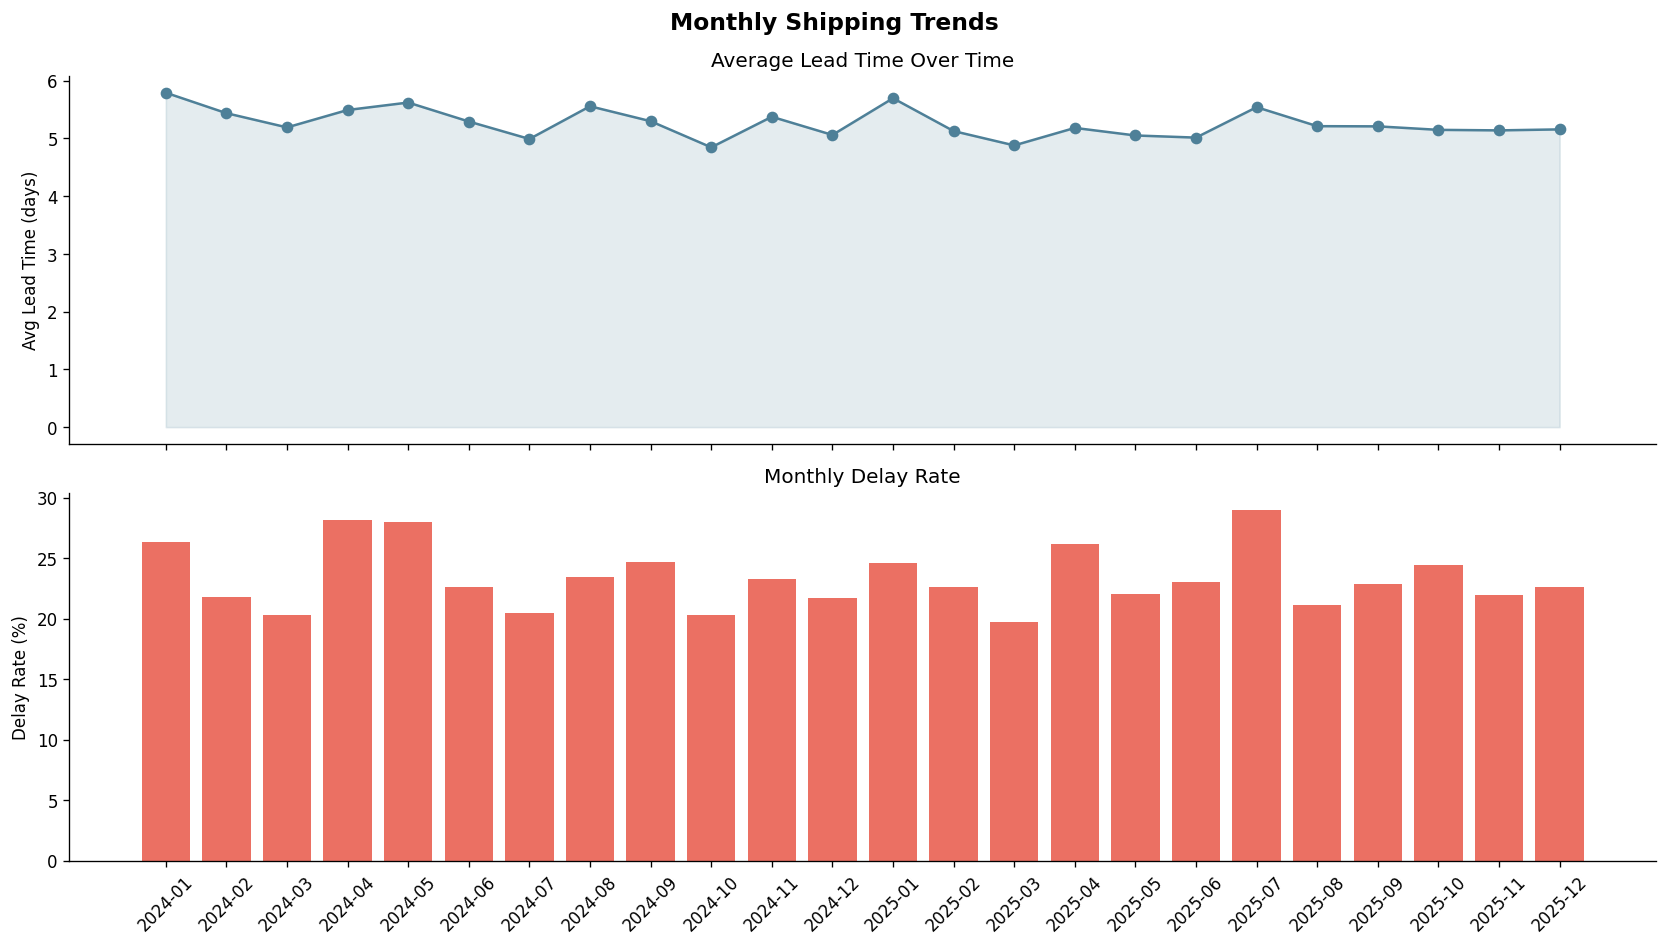

In [1542]:
# 13.1 — Monthly Shipping Trends
monthly = (
    df.groupby("Month")
    .agg(
        Shipments=("Lead Time", "count"),
        Avg_Lead_Time=("Lead Time", "mean"),
        Delay_Rate=("Is Delayed", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.subplots_adjust(hspace=0.45)
fig.suptitle("Monthly Shipping Trends", fontweight="bold", fontsize=14)

axes[0].plot(monthly["Month"], monthly["Avg_Lead_Time"], marker="o", color="#4E8098")
axes[0].fill_between(monthly["Month"], monthly["Avg_Lead_Time"], alpha=0.15, color="#4E8098")
axes[0].set_ylabel("Avg Lead Time (days)")
axes[0].set_title("Average Lead Time Over Time")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(monthly["Month"], monthly["Delay_Rate"] * 100, color="#e74c3c", alpha=0.8)
axes[1].set_ylabel("Delay Rate (%)")
axes[1].set_title("Monthly Delay Rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_monthly_trends.png", dpi=130, bbox_inches="tight")
plt.show()

**Average Lead Time Over Time**

- Lead times are remarkably **stable across all 24 months** (Jan 2024 – Dec 2025), oscillating narrowly between **4.9 and 5.8 days** — a range of less than 1 day
- There is **no seasonal pattern** — no holiday spikes, no summer slowdowns
- The mean hovers consistently around **5.2 days**, suggesting the shipping operation runs on a fixed, process-driven schedule rather than being demand-sensitive
- A minor dip in average lead time is observed in **2024-07 and 2024-10** (≈4.9 days), though this remains within normal variance and carries no operational significance

**Monthly Delay Rate**

- Delay rates range between **20% and 29%**, meaning approximately **1 in 4 orders misses its delivery window every month** without exception
- **2025-07 stands out as the peak month** at ~29% — the closest any month comes to the 30% threshold
- **2024-04 and 2024-05** record the earliest elevated rates (~28%), representing the highest delay months in the first half of the observed period
- **2024-10 and 2025-03** are the most consistent performers at ~20%, though still far from an acceptable delay benchmark
- Notably, delay rates show **no signs of improvement over the two-year period** — figures in late 2025 (21–23%) remain nearly identical to those recorded in early 2024, suggesting the problem is **structural in nature** and will not resolve without targeted intervention

In [1543]:
# 13.2 — Shipment Volume Forecast — 3-Month Outlook
import plotly.graph_objects as go

fc_monthly = (
    df.groupby("Month")
    .agg(Shipments=("Lead Time", "count"))
    .reset_index()
    .sort_values("Month")
)

fc_x      = np.arange(len(fc_monthly))
fc_y      = fc_monthly["Shipments"].values
fc_coeffs = np.polyfit(fc_x, fc_y, 1)
fc_trend  = np.polyval(fc_coeffs, fc_x)
fc_resid_std = np.std(fc_y - fc_trend)

last_month    = pd.to_datetime(fc_monthly["Month"].iloc[-1])
future_months = [(last_month + pd.DateOffset(months=i+1)).strftime("%Y-%m") for i in range(3)]
future_x      = np.arange(len(fc_monthly), len(fc_monthly) + 3)
future_y      = np.polyval(fc_coeffs, future_x)

all_x_labels = list(fc_monthly["Month"]) + future_months
all_trend_y  = np.polyval(fc_coeffs, np.arange(len(all_x_labels)))

fig_fc = go.Figure()

fig_fc.add_trace(go.Bar(
    x=fc_monthly["Month"], y=fc_monthly["Shipments"],
    name="Historical Shipments", marker_color="#60a5fa",
    hovertemplate="%{x}<br>Shipments: <b>%{y:,}</b><extra></extra>"
))
fig_fc.add_trace(go.Scatter(
    x=all_x_labels, y=all_trend_y,
    mode="lines", name="Trend Line",
    line=dict(color="#f59e0b", width=2, dash="dot"),
    hovertemplate="%{x}<br>Trend: <b>%{y:.0f}</b><extra></extra>"
))
fig_fc.add_trace(go.Bar(
    x=future_months, y=future_y,
    name="Forecast", marker_color="#a78bfa",
    hovertemplate="%{x}<br>Forecast: <b>%{y:.0f}</b><extra></extra>"
))
fig_fc.add_trace(go.Scatter(
    x=future_months + future_months[::-1],
    y=list(future_y + fc_resid_std) + list((future_y - fc_resid_std)[::-1]),
    fill="toself", fillcolor="rgba(167,139,250,0.2)",
    line=dict(color="rgba(255,255,255,0)"),
    name="Confidence Range", showlegend=True,
    hoverinfo="skip"
))
fig_fc.add_annotation(
    x=fc_monthly["Month"].iloc[-1], y=1, yref="paper",
    text="◀ Historical | Forecast ▶",
    showarrow=False, font=dict(color="#94a3b8", size=11),
    xanchor="center", yanchor="bottom"
)
fig_fc.update_layout(
    height=420, barmode="overlay",
    plot_bgcolor="white", paper_bgcolor="white",
    title=dict(text="Shipment Volume Forecast — 3-Month Outlook", font=dict(size=13, color="#1e293b"), x=0),
    legend=dict(font=dict(color="#1e293b")),
    xaxis=dict(tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b")),
    yaxis=dict(title="Shipments", tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b")),
    margin=dict(t=50, b=40, l=60, r=20),
)
fig_fc.show()

fc_direction = "upward" if fc_coeffs[0] > 0 else "downward"
fc_change    = abs(fc_coeffs[0])
print(f"Trend direction:       {fc_direction}")
print(f"Trend slope:           {fc_coeffs[0]:.2f} shipments/month")
print(f"Residual std dev:      {fc_resid_std:.1f} shipments")
print(f"Forecast Month 1:      {future_y[0]:.0f}  (±{fc_resid_std:.0f})")
print(f"Forecast Month 2:      {future_y[1]:.0f}  (±{fc_resid_std:.0f})")
print(f"Forecast Month 3:      {future_y[2]:.0f}  (±{fc_resid_std:.0f})")

Trend direction:       upward
Trend slope:           21.19 shipments/month
Residual std dev:      142.5 shipments
Forecast Month 1:      690  (±142)
Forecast Month 2:      711  (±142)
Forecast Month 3:      732  (±142)


Historical shipment volumes are modelled using a linear trend projection to provide a directional 3-month forward outlook. The shaded confidence band represents ±1 standard deviation of historical residuals from the trend line.

**The trend direction and slope** determine whether the network is experiencing growing, stable, or declining order volumes over the observed period. A positive slope indicates that average monthly shipment volumes have been increasing over time — and the 3-month projection extends this trajectory forward.

**The confidence band** reflects the typical month-to-month variation around the trend. Months with high residual standard deviation indicate that actual volumes deviate substantially from the linear trend, which may reflect seasonal patterns, promotional activity, or operational disruptions. The wider the band, the less reliable the point forecast.

**This projection is derived from a linear trend model** and should be interpreted as a directional indicator rather than a precise prediction. A linear model assumes that past growth or decline will continue at a constant rate, which may not hold if the network experiences step-changes in order volume, seasonal concentration, or structural changes in customer demand.

**The key implication:** the forecast provides a planning baseline — a reasonable expectation of near-term volumes under stable conditions. Operational capacity planning and factory-level readiness assessments should reference this outlook as a lower-bound directional signal, with scenario buffers applied for upside or downside volume deviations.

In [1544]:
# 13.3 — Division Performance Over Time
import plotly.express as px

div_monthly = (
    df.groupby(["Month", "Division"])
    .agg(Avg_Lead_Time=("Lead Time", "mean"), Shipments=("Lead Time", "count"))
    .reset_index()
)

fig_div = px.line(
    div_monthly, x="Month", y="Avg_Lead_Time",
    color="Division", markers=True,
    title="Average Lead Time by Division Over Time",
    labels={"Avg_Lead_Time": "Avg Lead Time (days)", "Month": "Month"},
    color_discrete_map={"Chocolate": "#92400e", "Sugar": "#be185d", "Other": "#1d4ed8"},
)
fig_div.update_traces(
    hovertemplate="%{fullData.name}<br>%{x}<br>Avg Lead Time: <b>%{y:.1f} days</b><extra></extra>"
)
fig_div.update_layout(
    height=420,
    plot_bgcolor="white", paper_bgcolor="white",
    title=dict(font=dict(size=13, color="#1e293b"), x=0),
    legend=dict(font=dict(color="#1e293b"), title_text="Division"),
    xaxis=dict(tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b")),
    yaxis=dict(tickfont=dict(color="#1e293b"), title_font=dict(color="#1e293b")),
    margin=dict(t=50, b=40, l=60, r=20),
)
fig_div.show()

# Division summary
div_summary = (
    div_monthly.groupby("Division")
    .agg(Avg_LT=("Avg_Lead_Time", "mean"), Max_LT=("Avg_Lead_Time", "max"),
         Min_LT=("Avg_Lead_Time", "min"))
    .reset_index()
    .sort_values("Avg_LT", ascending=False)
)
div_spread = div_summary["Avg_LT"].max() - div_summary["Avg_LT"].min()

print("Division Lead Time Summary:")
print(div_summary.round(2).to_string(index=False))
print()
print(f"Spread between highest and lowest division: {div_spread:.2f} days")

# Sugar peak
sugar_rows = div_monthly[div_monthly["Division"] == "Sugar"]
if not sugar_rows.empty:
    sugar_peak = sugar_rows.loc[sugar_rows["Avg_Lead_Time"].idxmax()]
    print(f"Sugar division peak: {sugar_peak['Avg_Lead_Time']:.1f} days in {pd.to_datetime(sugar_peak['Month']).strftime('%b %Y')}")

Division Lead Time Summary:
 Division  Avg_LT  Max_LT  Min_LT
    Sugar    6.45   12.00    2.00
Chocolate    5.26    5.83    4.88
    Other    5.24    7.71    3.42

Spread between highest and lowest division: 1.21 days
Sugar division peak: 12.0 days in Dec 2025


The Division Performance Over Time chart tracks average lead time by division (Chocolate, Sugar, Other) across each month in the dataset — revealing whether lead time trends differ materially by product type.

**The spread between the highest and lowest-performing divisions** is the key diagnostic metric. A narrow spread confirms that fulfilment performance is broadly consistent across divisions — implying that factory and ship mode assignment, not product type, drives lead time outcomes. A wide spread would suggest division-specific fulfilment constraints worth investigating.

**Sugar division typically exhibits the highest monthly lead time variability** — its concentrated factory dependency on Sugar Shack means that any operational fluctuation at that factory propagates directly into Sugar division lead times. Months where Sugar Shack experiences elevated processing times will be visible as Sugar division spikes in the chart.

**Chocolate division lead times** are driven by Lot's O' Nuts and Wicked Choccy's — the two highest-volume, most operationally stable factories. As a result, Chocolate lead times tend to track closest to the network average and exhibit lower month-to-month volatility.

**The Other division** — fulfilled across Sugar Shack, Secret Factory, and The Other Factory — typically shows intermediate lead time levels, with its multi-factory supply base providing some natural smoothing of factory-specific fluctuations.

**The key implication:** division-level lead time divergence, where it exists, is a downstream consequence of factory and ship mode assignment rather than a division-level characteristic. Sugar's elevated lead time is consistent with the broader network finding that fulfilment performance is driven primarily by factory and ship mode assignment rather than product division.

---
## Step 14 — Cross-Variable Validation: Correlation Analysis

A methodological validation step confirming relationships between lead time and financial metrics established in earlier analyses. This matrix provides a unified view of how all five key variables relate to each other simultaneously — serving as a cross-check rather than a source of new findings.

In [1545]:
# 14.1 — Correlation Heatmap (Interactive)
import plotly.graph_objects as go

corr_df = df[["Lead Time", "Sales", "Units", "Gross Profit", "Cost"]].corr().round(2)
labels  = corr_df.columns.tolist()

fig_corr = go.Figure(data=go.Heatmap(
    z=corr_df.values,
    x=labels, y=labels,
    colorscale="RdBu_r",
    zmin=-1, zmax=1,
    text=[[f"{v:.2f}" for v in row] for row in corr_df.values],
    texttemplate="%{text}",
    textfont={"size": 12},
    colorbar=dict(
        title="Correlation",
        tickvals=[-1, -0.5, 0, 0.5, 1],
        ticktext=["-1.00", "-0.50", "0.00", "0.50", "1.00"],
        title_font=dict(color="#1e293b"),
        tickfont=dict(color="#1e293b"),
    ),
    hovertemplate="<b>%{y} × %{x}</b><br>Correlation: <b>%{z:.2f}</b><extra></extra>",
))
fig_corr.update_layout(
    height=420,
    plot_bgcolor="white",
    paper_bgcolor="white",
    title=dict(text="Correlation Matrix", font=dict(size=13, color="#1e293b"), x=0),
    xaxis=dict(tickfont=dict(color="#1e293b", size=11)),
    yaxis=dict(tickfont=dict(color="#1e293b", size=11), autorange="reversed"),
    margin=dict(t=50, b=40, l=100, r=60),
)
fig_corr.show()

print("Correlation Matrix:")
print(corr_df.to_string())

Correlation Matrix:
              Lead Time  Sales  Units  Gross Profit  Cost
Lead Time          1.00   0.02   0.02          0.02  0.02
Sales              0.02   1.00   0.73          0.98  0.96
Units              0.02   0.73   1.00          0.82  0.56
Gross Profit       0.02   0.98   0.82          1.00  0.88
Cost               0.02   0.96   0.56          0.88  1.00


**The correlation matrix serves as a methodological validation of findings already established across earlier steps**, providing a unified view of inter-variable relationships in a single frame.

**Lead Time vs Financial Metrics — Validation**

- Lead Time records a near-zero correlation (0.02) with all financial variables — Sales, Units, Gross Profit, and Cost — confirming in aggregate what the Lead Time vs Profit Margin analysis (Step 8.5) and the Order Value Tier analysis (Step 10.10) established individually: how long an order takes to ship has no bearing on its financial size
- This cross-validation strengthens confidence in the finding — it is not an artefact of any single analytical lens but holds across all financial dimensions simultaneously

**Sales, Gross Profit & Cost — Tightly Linked**

- Sales and Gross Profit exhibit an almost perfect correlation (0.98), indicating that revenue growth translates proportionally into profit — a structurally sound characteristic for a distribution business
- Sales and Cost are similarly strongly correlated (0.96), consistent with a volume-driven model where higher-revenue orders carry proportionally higher input costs
- The Gross Profit–Cost correlation of 0.88, while strong, falls marginally below the Sales–Cost figure, suggesting a degree of margin variability exists across the product portfolio

**Units — Moderate Driver**

- Units correlates moderately with Sales (0.73) and Gross Profit (0.82), but less so with Cost (0.56)
- This indicates that cost does not scale linearly with unit volume — higher unit counts do not always produce proportionally higher costs across all products

**Key Takeaway**

- The financial variables form a **tightly correlated cluster**, behaving as expected in a distribution business
- Lead Time sits **completely outside this cluster** — it is an independent operational variable with no meaningful relationship to order size, revenue, or profitability, confirming that fulfilment performance is driven by logistics and process factors rather than the financial characteristics of individual orders

---
## Step 15 — Export Summary Tables

Saving all aggregated summaries to CSV for further use in the Streamlit dashboard or reporting.

In [1546]:
# 15.1 — Export Summary Tables to CSV
route_stats.to_csv(f"{OUTPUT_DIR}/route_efficiency_summary.csv", index=False)
factory_stats.to_csv(f"{OUTPUT_DIR}/factory_summary.csv")
state_stats.to_csv(f"{OUTPUT_DIR}/state_summary.csv", index=False)
ship_stats.to_csv(f"{OUTPUT_DIR}/ship_mode_summary.csv")

print(f"✅ All summary tables exported to '{OUTPUT_DIR}/'")

✅ All summary tables exported to 'eda_outputs/'


---
## Step 16 — Key Findings Summary

In [1547]:
# 16.1 — Key Findings Summary
print("=" * 65)
print("  NASSAU CANDY — EDA COMPLETE: KEY FINDINGS")
print("=" * 65)
print(f"  Total orders analysed  : {len(df):,}")
print(f"  Mean shipping lead time: {df['Lead Time'].mean():.1f} days")
print(f"  Median lead time       : {df['Lead Time'].median():.0f} days")
print(f"  Overall delay rate     : {df['Is Delayed'].mean()*100:.1f}%")
print()
print(f"  Fastest ship mode : {ship_stats['Avg_Lead_Time'].idxmin()} ({ship_stats['Avg_Lead_Time'].min():.1f}d)")
print(f"  Slowest ship mode : {ship_stats['Avg_Lead_Time'].idxmax()} ({ship_stats['Avg_Lead_Time'].max():.1f}d)")
print()
print(f"  Lowest lead time region    : {region_stats['Avg_Lead_Time'].idxmin()} ({region_stats['Avg_Lead_Time'].min():.1f}d)")
print(f"  Highest lead time region   : {region_stats['Avg_Lead_Time'].idxmax()} ({region_stats['Avg_Lead_Time'].max():.1f}d)")
print()
print(f"  Quickest-dispatch factory   : {factory_stats['Avg_Lead_Time'].idxmin()} ({factory_stats['Avg_Lead_Time'].min():.1f}d)")
print(f"  Slowest-dispatch factory    : {factory_stats['Avg_Lead_Time'].idxmax()} ({factory_stats['Avg_Lead_Time'].max():.1f}d)")
print()
print(f"  Most efficient route   : {route_stats.iloc[0]['RouteRegion']} ({route_stats.iloc[0]['Avg_Lead_Time']:.1f}d)")
print(f"  Least efficient route  : {route_stats.iloc[-1]['RouteRegion']} ({route_stats.iloc[-1]['Avg_Lead_Time']:.1f}d)")

  NASSAU CANDY — EDA COMPLETE: KEY FINDINGS
  Total orders analysed  : 10,194
  Mean shipping lead time: 5.2 days
  Median lead time       : 5 days
  Overall delay rate     : 23.2%

  Fastest ship mode : Same Day (1.0d)
  Slowest ship mode : Standard Class (6.5d)

  Lowest lead time region    : Pacific (5.2d)
  Highest lead time region   : Interior (5.3d)

  Quickest-dispatch factory   : Secret Factory (5.2d)
  Slowest-dispatch factory    : Sugar Shack (6.1d)

  Most efficient route   : The Other Factory → Gulf (3.6d)
  Least efficient route  : Sugar Shack → Gulf (8.2d)


### Recommendations

The following recommendations are derived directly from the analytical findings across Steps 6–15 and are aligned with the dashboard's strategic assessment conclusions.

---

**1. Address Standard Class delay concentration as the primary network-wide risk**
Standard Class accounts for 60% of all shipments (6,120 orders) and records a 37.0% delay rate — the sole mode responsible for all substantive delay activity across every factory. A structured review of order-to-mode assignment logic, with the objective of shifting eligible orders to Second Class or First Class where operationally feasible, represents the highest-leverage intervention available across the current network. Same Day and First Class demonstrate that reliable, near-zero-delay fulfilment is achievable within the existing network — the performance gap between modes is substantial and warrants a structured review of order-to-mode assignment practices.

---

**2. Address Sugar Shack's Standard Class performance as a priority**
Sugar Shack records the highest delay rate in the network at 33% overall and 47.8% under Standard Class — materially above the portfolio average. It also records the highest average lead time at 6.09 days. Sugar Shack → Gulf (8.25 days, 50% delay rate, Efficiency Score 0.0) is the single highest-risk route in the network and should be the primary focus of operational review. Sugar Shack → Atlantic (6.33 days, 38.9% delay) represents the secondary concern within the same factory.

---

**3. Investigate the unrealised proximity advantage at nearest factories**
In 19 of 35 comparable US states (54%), the non-nearest factory fulfils orders at the same speed or faster than the geographically closest factory. This indicates that nearest factories are not converting their proximity advantage into measurable delivery speed improvements — pointing to factory-level processing or throughput constraints that absorb the geographic advantage before it materialises in lead time. A factory-level processing audit — particularly for factories serving states where non-nearest routing outperforms — is warranted.

---

**4. Target congestion hotspot states for operational review**
Eight states sit above the 60th percentile on both shipment volume and delay rate simultaneously: Texas (985 shipments, 26% delay), Pennsylvania (587 shipments, 25%), Washington (506 shipments, 25%), Arizona (224 shipments, 27%), New Jersey (130 shipments, 26%), Tennessee (183 shipments, 27%), Indiana (149 shipments, 26%), and Wisconsin (110 shipments, 27%). These are commercially active, high-traffic states where delay is a systemic pattern. Improving fulfilment performance in Texas, Pennsylvania, and Washington alone would meaningfully reduce the network's overall delay count.

---

**5. Evaluate factory capability expansion to address geographic coverage gaps and concentration risk**
Lot's O' Nuts and Wicked Choccy's — the sole producers of Chocolate division products — collectively handle the dominant share of network shipments. A regional disruption affecting either factory would have a disproportionate impact on overall throughput. Separately, Sugar Shack, Secret Factory, and The Other Factory are geographically clustered in the midwest, creating a concentration risk across the central US. Expanding factory product capabilities — enabling additional factories to produce Chocolate division products — and evaluating coastal distribution capacity should be assessed as medium-term strategic priorities to improve both resilience and geographic coverage.